In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image


class BUSIDataset(Dataset):
    def __init__(
        self,
        img_dir,
        mask_dir,
        transform=None,
        mask_transform=None
    ):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mask_transform = mask_transform

        valid_exts = (".jpg", ".jpeg", ".png", ".bmp")

        all_images = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(valid_exts)
        ])

        mask_files = {
            os.path.splitext(m)[0]
            for m in os.listdir(mask_dir)
            if m.lower().endswith(valid_exts)
        }

        self.images = []

        for img_name in all_images:

            base_name = os.path.splitext(img_name)[0]

            mask_base_name = base_name + "_mask"

            if mask_base_name in mask_files:
                self.images.append(img_name)

        print(f"Found {len(self.images)} image-mask pairs.")

    def get_base_name(self, filename):
        return os.path.splitext(filename)[0]

    def get_class(self, filename):

        base_name = self.get_base_name(filename).lower()

        if base_name.startswith("benign"):
            return 0

        elif base_name.startswith("malignant"):
            return 1

        elif base_name.startswith("normal"):
            return 2

        else:
            raise ValueError(
                f"Unknown BUSI class for file: {filename}"
            )

    def load_mask(self, base_name):

        valid_exts = (".jpg", ".jpeg", ".png", ".bmp")

        mask_base_name = base_name + "_mask"

        for ext in valid_exts:

            mask_path = os.path.join(
                self.mask_dir,
                mask_base_name + ext
            )

            if os.path.exists(mask_path):

                mask = np.array(
                    Image.open(mask_path).convert("L")
                )

                mask = (mask > 127).astype(np.uint8)

                return Image.fromarray(mask * 255)

        raise FileNotFoundError(
            f"No mask found for '{base_name}' "
            f"in '{self.mask_dir}'"
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(
            self.img_dir,
            img_name
        )

        base_name = self.get_base_name(img_name)

        image = Image.open(img_path).convert("RGB")

        mask_pil = self.load_mask(base_name)

        if self.transform:
            image = self.transform(image)

        if self.mask_transform:

            mask = self.mask_transform(mask_pil)

            mask = (mask > 0.5).long().squeeze(0)

        else:

            mask = torch.tensor(
                (np.array(mask_pil) > 127).astype(np.uint8),
                dtype=torch.long
            )

        label = torch.tensor(
            self.get_class(img_name),
            dtype=torch.long
        )

        return image, mask, label

In [3]:
dataset = BUSIDataset(
    "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images",
    "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks"
)

img, mask, label = dataset[0]

print(torch.unique(mask))
print(torch.unique(label))

Found 647 image-mask pairs.
tensor([0, 1])
tensor([0])


In [4]:
from collections import Counter

class_counter = Counter()
total_masks = 0
missing_masks = 0
missing_images_list = []

for i in range(len(dataset)):

    img_name = dataset.images[i]

    img, mask, label = dataset[i]

    if label.item() == 0:
        class_counter["benign"] += 1
    elif label.item() == 1:
        class_counter["malignant"] += 1
    elif label.item() == 2:
        class_counter["normal"] += 1
    else:
        class_counter["unknown"] += 1

    if mask.sum().item() > 0:
        total_masks += 1
    else:
        missing_masks += 1
        missing_images_list.append(img_name)

    if (i + 1) % 100 == 0:
        print(
            f"  Processed {i + 1}/{len(dataset)} images..."
        )


print("\n===== BUSI DATASET SUMMARY =====")

print("Total images         :", len(dataset))
print("Total classes        :", len(class_counter))
print("Class distribution   :", dict(class_counter))

print("Images with masks    :", total_masks)
print("Images without masks :", missing_masks)


if missing_images_list:

    print("\n===== IMAGES WITHOUT / EMPTY MASKS =====")

    for name in missing_images_list:
        print(" ", name)

else:

    print(
        "\n✓ All images have valid non-empty "
        "breast-lesion masks."
    )

  Processed 100/647 images...
  Processed 200/647 images...
  Processed 300/647 images...
  Processed 400/647 images...
  Processed 500/647 images...
  Processed 600/647 images...

===== BUSI DATASET SUMMARY =====
Total images         : 647
Total classes        : 2
Class distribution   : {'benign': 437, 'malignant': 210}
Images with masks    : 647
Images without masks : 0

✓ All images have valid non-empty breast-lesion masks.


In [5]:
import torch

labels_all = []

for i in range(len(dataset)):
    _, _, label = dataset[i]
    labels_all.append(label.item())

labels_all = torch.tensor(labels_all)

print("Unique classes in dataset:", torch.unique(labels_all))

Unique classes in dataset: tensor([0, 1])


In [6]:
import numpy as np

def perfect_split(dataset, train_ratio=0.8, val_ratio=0.10, test_ratio=0.10, random_state=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    indices = np.arange(len(dataset))

    rng = np.random.default_rng(random_state)
    shuffled = rng.permutation(indices)

    n_train = int(len(shuffled) * train_ratio)
    n_val   = int(len(shuffled) * val_ratio)

    train_idx = shuffled[:n_train]
    val_idx   = shuffled[n_train : n_train + n_val]
    test_idx  = shuffled[n_train + n_val:]

    return {
        'train': train_idx.tolist(),
        'val':   val_idx.tolist(),
        'test':  test_idx.tolist()
    }

splits = perfect_split(dataset)

print(f"Total images : {len(dataset)}")
print(f"Train set    : {len(splits['train'])} images")
print(f"Val set      : {len(splits['val'])} images")
print(f"Test set     : {len(splits['test'])} images")

assert len(set(splits['train']) & set(splits['val']))  == 0, "Train/Val overlap!"
assert len(set(splits['train']) & set(splits['test'])) == 0, "Train/Test overlap!"
assert len(set(splits['val'])   & set(splits['test'])) == 0, "Val/Test overlap!"
print("\n✓ No overlap between splits.")

Total images : 647
Train set    : 517 images
Val set      : 64 images
Test set     : 66 images

✓ No overlap between splits.


In [8]:
import random
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torch.nn.functional as F

image_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def mask_transform(mask):
    mask = mask.unsqueeze(0).unsqueeze(0).float()
    mask = F.interpolate(mask, size=(256, 256), mode='nearest')
    mask = mask.squeeze().long()
    return mask

def augment(img, mask):
    if random.random() > 0.5:
        img  = TF.hflip(img)
        mask = torch.flip(mask, dims=[1])

    if random.random() > 0.5:
        img  = TF.vflip(img)
        mask = torch.flip(mask, dims=[0])

    angle = random.uniform(-20, 20)
    img  = TF.rotate(img, angle)
    mask = TF.rotate(
        mask.unsqueeze(0), angle,
        interpolation=TF.InterpolationMode.NEAREST
    ).squeeze(0)

    if random.random() > 0.5:
        i, j, h, w = T.RandomResizedCrop.get_params(
            img, scale=(0.75, 1.0), ratio=(0.9, 1.1)
        )
        img  = TF.resized_crop(img,  i, j, h, w, size=(256, 256))
        mask = TF.resized_crop(
            mask.unsqueeze(0), i, j, h, w,
            size=(256, 256),
            interpolation=TF.InterpolationMode.NEAREST
        ).squeeze(0)

    return img, mask

class TransformedDataset(Dataset):
    def __init__(self, base_dataset, image_transform=None,
                 mask_transform=None, augment=False):
        self.base_dataset     = base_dataset
        self.image_transform  = image_transform
        self.mask_transform   = mask_transform
        self.do_augment       = augment

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, mask, label = self.base_dataset[idx]

        if self.do_augment:
            img, mask = augment(img, mask)

        if self.image_transform:
            img = self.image_transform(img)

        if self.mask_transform:
            mask = self.mask_transform(mask)

        if self.do_augment:
            if random.random() > 0.5:
                img = img + random.uniform(-0.15, 0.15)

            if random.random() > 0.5:
                img = img * random.uniform(0.8, 1.2)

            if random.random() > 0.5:
                shift = torch.randn(3, 1, 1) * 0.05
                img   = img + shift

            if random.random() > 0.5:
                img = img + torch.randn_like(img) * 0.02

            img = torch.clamp(img, -2.5, 2.5)

        return img, mask, label

In [9]:
from torch.utils.data import Subset

train_dataset = Subset(dataset, splits['train'])
val_dataset   = Subset(dataset, splits['val'])
test_dataset  = Subset(dataset, splits['test'])

train_dataset = TransformedDataset(
    train_dataset,
    image_transform=image_transform,
    mask_transform=mask_transform,
    # augment=True
    augment=False
)

val_dataset = TransformedDataset(
    val_dataset,
    image_transform=image_transform,
    mask_transform=mask_transform,
    augment=False
)

test_dataset = TransformedDataset(
    test_dataset,
    image_transform=image_transform,
    mask_transform=mask_transform,
    augment=False
)

In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        intersection = (probs * targets).sum(dim=(2,3))
        union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))

        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.7, bce_weight=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.bce  = nn.BCEWithLogitsLoss()
        self.dw   = dice_weight
        self.bw   = bce_weight

    def forward(self, logits, targets):
        targets = targets.unsqueeze(1).float()
        return self.dw * self.dice(logits, targets) + \
               self.bw * self.bce(logits, targets)


def dice_score(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.4).float()

    targets = targets.unsqueeze(1).float()

    intersection = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3))

    dice = (2 * intersection + smooth) / (union + smooth)
    return dice.mean()


def iou_score(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.4).float()

    targets = targets.unsqueeze(1).float()

    intersection = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

# DeepLabV3+

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights


class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256):
        super().__init__()

        self.branch1 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.branch2 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=6,
                dilation=6,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.branch3 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=12,
                dilation=12,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.branch4 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=18,
                dilation=18,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.project = nn.Sequential(
            nn.Conv2d(
                out_channels * 5,
                out_channels,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Dropout(0.5)
        )

    def forward(self, x):

        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)

        b5 = self.global_pool(x)

        b5 = F.interpolate(
            b5,
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [b1, b2, b3, b4, b5],
            dim=1
        )

        x = self.project(x)

        return x


class DeepLabV3PlusDecoder(nn.Module):
    def __init__(
        self,
        low_level_channels=256,
        high_level_channels=256,
        decoder_channels=256,
        out_channels=1
    ):
        super().__init__()

        self.low_level_projection = nn.Sequential(
            nn.Conv2d(
                low_level_channels,
                48,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        self.decoder = nn.Sequential(

            nn.Conv2d(
                48 + high_level_channels,
                decoder_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(decoder_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                decoder_channels,
                decoder_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(decoder_channels),
            nn.ReLU(inplace=True)
        )

        self.segmentation_head = nn.Conv2d(
            decoder_channels,
            out_channels,
            kernel_size=1
        )

    def forward(
        self,
        high_level_features,
        low_level_features,
        output_size
    ):

        high_level_features = F.interpolate(
            high_level_features,
            size=low_level_features.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        low_level_features = self.low_level_projection(
            low_level_features
        )

        x = torch.cat(
            [
                high_level_features,
                low_level_features
            ],
            dim=1
        )

        x = self.decoder(x)

        x = self.segmentation_head(x)

        x = F.interpolate(
            x,
            size=output_size,
            mode="bilinear",
            align_corners=False
        )

        return x


class DeepLabV3Plus(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        pretrained=True
    ):
        super().__init__()

        if pretrained:
            weights = ResNet50_Weights.DEFAULT
        else:
            weights = None

        backbone = resnet50(weights=weights)

        if in_channels != 3:

            old_conv = backbone.conv1

            backbone.conv1 = nn.Conv2d(
                in_channels,
                64,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False
            )

            nn.init.kaiming_normal_(
                backbone.conv1.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.aspp = ASPP(
            in_channels=2048,
            out_channels=256
        )

        self.decoder = DeepLabV3PlusDecoder(
            low_level_channels=256,
            high_level_channels=256,
            decoder_channels=256,
            out_channels=out_channels
        )

    def forward(self, x):

        input_size = x.shape[2:]

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        low_level_features = self.layer1(x)

        x = self.layer2(low_level_features)

        x = self.layer3(x)

        x = self.layer4(x)

        x = self.aspp(x)

        logits = self.decoder(
            high_level_features=x,
            low_level_features=low_level_features,
            output_size=input_size
        )

        return logits


model = DeepLabV3Plus(
    in_channels=3,
    out_channels=1,
    pretrained=True
).to(device)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("DeepLabV3+")
print("=" * 60)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("=" * 60)


x = torch.randn(
    2,
    3,
    256,
    256
).to(device)

with torch.no_grad():
    logits = model(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {logits.shape}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 235MB/s]


DeepLabV3+
Total parameters:     40,347,041
Trainable parameters: 40,347,041
Input shape:  torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = CombinedLoss().to(device)
num_epochs = 200
aux_weight = 0.6

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

def deep_supervision_loss(criterion, main_logits, aux_logits_list, masks, aux_weight=0.4):
    loss = criterion(main_logits, masks)
    for aux in aux_logits_list:
        loss = loss + aux_weight * criterion(aux, masks)
    return loss

class EarlyStopping:
    def __init__(self, patience=15, verbose=True):
        self.patience   = patience
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.stop       = False
    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), "best_model.pth")
            if self.verbose:
                print(f"  Val loss improved to {self.best_loss:.4f} — model saved.")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement. EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                print("  Early stopping triggered.")
                self.stop = True

early_stopping = EarlyStopping(patience=15, verbose=True)
train_losses, val_losses = [], []
train_dices, val_dices   = [], []
train_ious, val_ious     = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou  = 0.0

    for imgs, masks, labels in train_loader:
        imgs  = imgs.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(imgs)
        if isinstance(outputs, (list, tuple)):
            main_logits = outputs[0]
            aux_logits  = outputs[1:]
        else:
            main_logits = outputs
            aux_logits  = []

        loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(main_logits, masks).item()
        train_iou  += iou_score(main_logits, masks).item()

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou  = 0.0

    with torch.no_grad():
        for imgs, masks, labels in val_loader:
            imgs  = imgs.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)

            outputs = model(imgs)
            if isinstance(outputs, (list, tuple)):
                main_logits = outputs[0]
                aux_logits  = outputs[1:]
            else:
                main_logits = outputs
                aux_logits  = []

            loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

            val_loss += loss.item()
            val_dice += dice_score(main_logits, masks).item()
            val_iou  += iou_score(main_logits, masks).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice   = val_dice   / len(val_loader)
    avg_train_iou  = train_iou  / len(train_loader)
    avg_val_iou    = val_iou    / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)
    train_ious.append(avg_train_iou)
    val_ious.append(avg_val_iou)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Dice: {avg_val_dice:.4f} | "
          f"IoU: {avg_val_iou:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    scheduler.step()
    early_stopping(avg_val_loss, model)
    if early_stopping.stop:
        print(f"\nTraining stopped early at epoch {epoch+1}.")
        break

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
print("\nBest model loaded for evaluation.")

Epoch [1/200] Train Loss: 0.6275 | Val Loss: 0.5234 | Dice: 0.5482 | IoU: 0.4314 | LR: 3.00e-04
  ✅ Val loss improved to 0.5234 — model saved.
Epoch [2/200] Train Loss: 0.4183 | Val Loss: 0.3763 | Dice: 0.6850 | IoU: 0.5616 | LR: 3.00e-04
  ✅ Val loss improved to 0.3763 — model saved.
Epoch [3/200] Train Loss: 0.3034 | Val Loss: 0.3229 | Dice: 0.7069 | IoU: 0.5919 | LR: 3.00e-04
  ✅ Val loss improved to 0.3229 — model saved.
Epoch [4/200] Train Loss: 0.2282 | Val Loss: 0.2893 | Dice: 0.7081 | IoU: 0.5906 | LR: 3.00e-04
  ✅ Val loss improved to 0.2893 — model saved.
Epoch [5/200] Train Loss: 0.1946 | Val Loss: 0.2864 | Dice: 0.7257 | IoU: 0.6220 | LR: 3.00e-04
  ✅ Val loss improved to 0.2864 — model saved.
Epoch [6/200] Train Loss: 0.1670 | Val Loss: 0.2773 | Dice: 0.7375 | IoU: 0.6320 | LR: 3.00e-04
  ✅ Val loss improved to 0.2773 — model saved.
Epoch [7/200] Train Loss: 0.1420 | Val Loss: 0.2173 | Dice: 0.7795 | IoU: 0.6738 | LR: 2.99e-04
  ✅ Val loss improved to 0.2173 — model saved.

In [15]:
import torch
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt

def get_boundary(mask):
    mask = mask.astype(bool)
    return mask ^ binary_erosion(mask) if mask.any() else np.zeros_like(mask, dtype=bool)

def boundary_f1(pred, gt, tolerance=2):
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any(): return 0.0
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    precision = np.mean(gt_dist[pred_b] <= tolerance)
    recall = np.mean(pred_dist[gt_b] <= tolerance)
    return float(2 * precision * recall / (precision + recall + 1e-6))

def surface_distances(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() or not gt.any(): return np.nan, np.nan
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any(): return np.nan, np.nan
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    d_pred_gt, d_gt_pred = gt_dist[pred_b], pred_dist[gt_b]
    assd = (d_pred_gt.sum() + d_gt_pred.sum()) / (len(d_pred_gt) + len(d_gt_pred))
    hd95 = max(np.percentile(d_pred_gt, 95), np.percentile(d_gt_pred, 95))
    return float(assd), float(hd95)

def evaluate_segmentation(model, test_loader, device, threshold=0.4):
    model.eval().to(device)
    dice_all, iou_all, bf1_all, assd_all, hd95_all = [[], []], [[], []], [[], []], [[], []], [[], []]
    TP, FP, FN = [0, 0], [0, 0], [0, 0]
    total_correct = total_pixels = 0

    with torch.inference_mode():
        for imgs, masks, labels in test_loader:
            imgs = imgs.to(device, dtype=torch.float32, non_blocking=True)
            masks = masks.cpu()
            preds = (torch.sigmoid(model(imgs)) > threshold).squeeze(1).cpu()
            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()
            del imgs

            for b in range(preds.size(0)):
                pred = preds[b].numpy().astype(np.uint8)
                gt = masks[b].numpy().astype(np.uint8)

                for c in range(2):
                    p, g = pred == c, gt == c
                    inter = np.logical_and(p, g).sum()
                    p_sum, g_sum = p.sum(), g.sum()
                    union = p_sum + g_sum
                    dice_all[c].append((2 * inter + 1e-6) / (union + 1e-6))
                    iou_all[c].append((inter + 1e-6) / (union - inter + 1e-6))

                    TP[c] += int(np.logical_and(p, g).sum())
                    FP[c] += int(np.logical_and(p, ~g).sum())
                    FN[c] += int(np.logical_and(~p, g).sum())

                    bf1_all[c].append(boundary_f1(p, g, tolerance=2))
                    assd, hd95 = surface_distances(p, g)
                    if not np.isnan(assd):
                        assd_all[c].append(assd)
                        hd95_all[c].append(hd95)

            del preds, masks
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    precision, recall, f1 = [], [], []
    for c in range(2):
        p = TP[c] / (TP[c] + FP[c] + 1e-6)
        r = TP[c] / (TP[c] + FN[c] + 1e-6)
        precision.append(p)
        recall.append(r)
        f1.append(2 * p * r / (p + r + 1e-6))

    def mean(x): return float(np.mean(x)) if x else 0.0
    def std(x): return float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    names = ["Background", "Polyp"]
    print("\n==================== Test Set Metrics ====================")
    print(f"Overall Pixel Accuracy : {total_correct / (total_pixels + 1e-6):.4f}")
    print("----------------------------------------------------------")
    print(f"{'Class':<15}{'Dice':>8}{'IoU':>8}{'BF1':>8}{'ASSD':>9}{'HD95':>9}{'F1':>8}")
    print("----------------------------------------------------------")

    metrics = {}
    for c in range(2):
        d, i, b, a, h = map(mean, [dice_all[c], iou_all[c], bf1_all[c], assd_all[c], hd95_all[c]])
        metrics[c] = {"dice": d, "iou": i, "bf1": b, "assd": a, "hd95": h}
        print(f"{names[c]:<15}{d:8.4f}{i:8.4f}{b:8.4f}{a:9.2f}{h:9.2f}{f1[c]:8.4f}")

    mean_dice = np.mean([metrics[0]["dice"], metrics[1]["dice"]])
    mean_iou = np.mean([metrics[0]["iou"], metrics[1]["iou"]])
    mean_bf1 = np.mean([metrics[0]["bf1"], metrics[1]["bf1"]])
    mean_assd = np.mean([metrics[0]["assd"], metrics[1]["assd"]])
    mean_hd95 = np.mean([metrics[0]["hd95"], metrics[1]["hd95"]])
    mean_f1 = np.mean(f1)

    print("----------------------------------------------------------")
    print(f"{'Mean':<15}{mean_dice:8.4f}{mean_iou:8.4f}{mean_bf1:8.4f}{mean_assd:9.2f}{mean_hd95:9.2f}{mean_f1:8.4f}")
    print("==========================================================")

    accuracy = total_correct / (total_pixels + 1e-6)
    print("\n── Polyp Class (Primary Metrics) ──")
    print(f"Dice       : {metrics[1]['dice']:.4f}")
    print(f"IoU        : {metrics[1]['iou']:.4f}")
    print(f"Boundary F1: {metrics[1]['bf1']:.4f}")
    print(f"ASSD       : {metrics[1]['assd']:.2f}")
    print(f"HD95       : {metrics[1]['hd95']:.2f}")
    print(f"Precision  : {precision[1]:.4f}")
    print(f"Recall     : {recall[1]:.4f}")
    print(f"F1         : {f1[1]:.4f}")
    print("==========================================================\n")

    return {
        "accuracy": accuracy,
        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_boundary_f1": mean_bf1,
        "mean_assd": mean_assd,
        "mean_hd95": mean_hd95,
        "mean_f1": mean_f1,
        "polyp_dice": metrics[1]["dice"],
        "polyp_iou": metrics[1]["iou"],
        "polyp_boundary_f1": metrics[1]["bf1"],
        "polyp_assd": metrics[1]["assd"],
        "polyp_hd95": metrics[1]["hd95"],
        "polyp_precision": precision[1],
        "polyp_recall": recall[1],
        "polyp_f1": f1[1]
    }

results = evaluate_segmentation(model, test_loader, device=device, threshold=0.4)


==================== Test Set Metrics ====================
Overall Pixel Accuracy : 0.9520
----------------------------------------------------------
Class              Dice     IoU     BF1     ASSD     HD95      F1
----------------------------------------------------------
Background       0.9710  0.9468  0.8624     2.18    18.36  0.9735
Polyp            0.7250  0.6294  0.3653    13.40    33.81  0.7412
----------------------------------------------------------
Mean             0.8480  0.7881  0.6139     7.79    26.09  0.8573

── Polyp Class (Primary Metrics) ──
Dice       : 0.7250
IoU        : 0.6294
Boundary F1: 0.3653
ASSD       : 13.40
HD95       : 33.81
Precision  : 0.7372
Recall     : 0.7451
F1         : 0.7412



Image:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png

Ground Truth Mask:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png


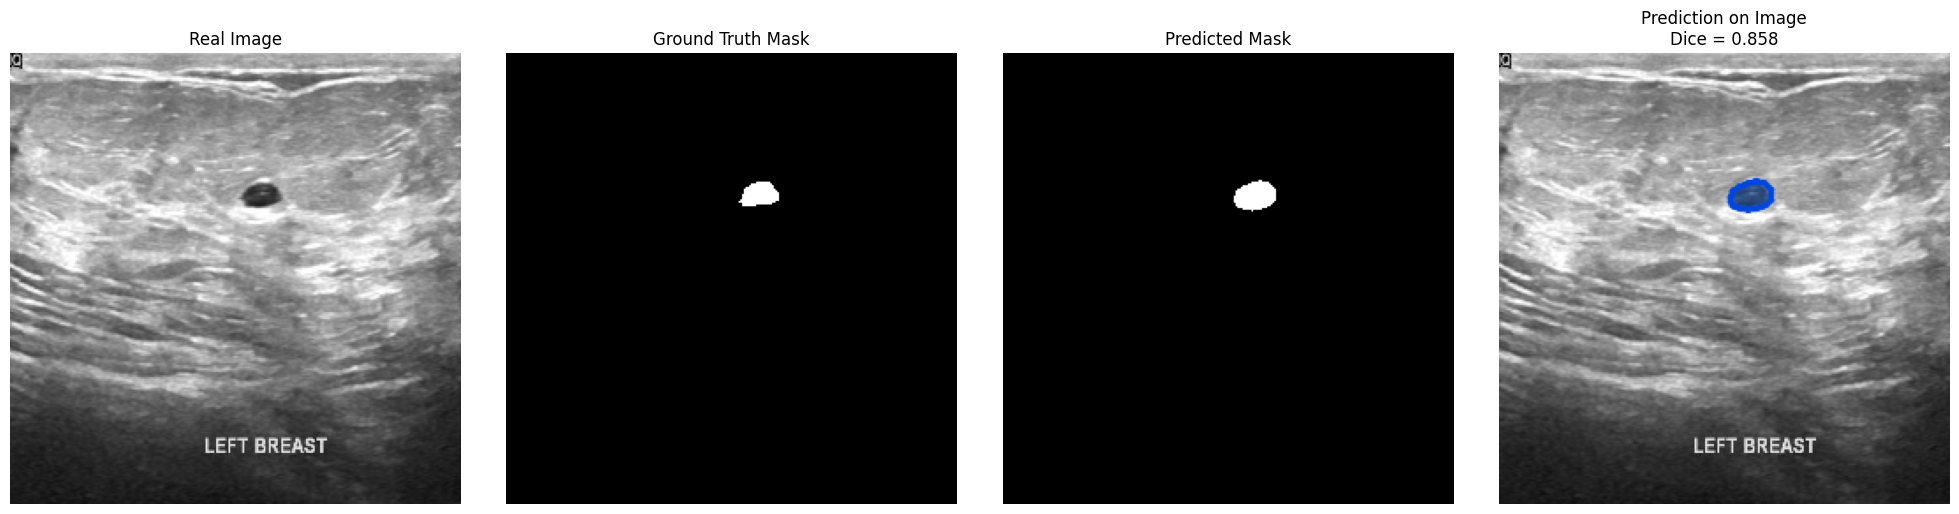


Visualization completed!
Image       : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png
GT Mask     : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png
Dice        : 0.8577

Saved files:
/kaggle/working/UNet/XAI/real_image.png
/kaggle/working/UNet/XAI/ground_truth_mask.png
/kaggle/working/UNet/XAI/predicted_mask.png
/kaggle/working/UNet/XAI/predicted_mask_on_image.png


In [17]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


IMAGE_PATH = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png"

MASK_DIR = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks"

SAVE_DIR = "/kaggle/working/UNet/XAI"
os.makedirs(SAVE_DIR, exist_ok=True)


THRESHOLD = 0.4

MASK_COLOR = np.array([30, 120, 255], dtype=np.uint8)

BORDER_COLOR = (0, 70, 220)

MASK_ALPHA = 0.35
BORDER_WIDTH = 2


image_filename = os.path.basename(IMAGE_PATH)

base_name = os.path.splitext(image_filename)[0]

mask_path = os.path.join(
    MASK_DIR,
    base_name + "_mask.png"
)

if not os.path.exists(mask_path):

    found_mask = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:

        temp_path = os.path.join(
            MASK_DIR,
            base_name + "_mask" + ext
        )

        if os.path.exists(temp_path):
            found_mask = temp_path
            break

    if found_mask is None:
        raise FileNotFoundError(
            f"Mask not found for:\n{IMAGE_PATH}\n\n"
            f"Expected mask similar to:\n"
            f"{base_name}_mask.png"
        )

    mask_path = found_mask


print("Image:")
print(IMAGE_PATH)

print("\nGround Truth Mask:")
print(mask_path)


original_pil = Image.open(IMAGE_PATH).convert("RGB")

original_image = np.array(original_pil)


gt_pil = Image.open(mask_path).convert("L")

gt_mask_original = np.array(gt_pil)

gt_mask_original = (
    gt_mask_original > 127
).astype(np.uint8)


model_input = image_transform(original_pil)

model_input = model_input.unsqueeze(0).to(device)


model.eval()

with torch.no_grad():

    output = model(model_input)

    if isinstance(output, (tuple, list)):
        output = output[0]

    probability = torch.sigmoid(output)

    predicted_mask = (
        probability > THRESHOLD
    ).long()


predicted_mask = predicted_mask.squeeze().cpu().numpy().astype(np.uint8)


output_h, output_w = predicted_mask.shape

gt_mask = cv2.resize(
    gt_mask_original,
    (output_w, output_h),
    interpolation=cv2.INTER_NEAREST
)

gt_mask = (
    gt_mask > 0
).astype(np.uint8)


display_image = cv2.resize(
    original_image,
    (output_w, output_h),
    interpolation=cv2.INTER_LINEAR
)

display_image = np.ascontiguousarray(
    display_image,
    dtype=np.uint8
)


gt_mask_display = (
    gt_mask * 255
).astype(np.uint8)


pred_mask_display = (
    predicted_mask * 255
).astype(np.uint8)


overlay = display_image.copy()

prediction_pixels = predicted_mask == 1

overlay[prediction_pixels] = (
    overlay[prediction_pixels].astype(np.float32)
    * (1 - MASK_ALPHA)
    +
    MASK_COLOR.astype(np.float32)
    * MASK_ALPHA
).astype(np.uint8)


contours, _ = cv2.findContours(
    predicted_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = np.ascontiguousarray(overlay)

cv2.drawContours(
    overlay,
    contours,
    -1,
    BORDER_COLOR,
    BORDER_WIDTH,
    lineType=cv2.LINE_AA
)


intersection = np.logical_and(
    predicted_mask == 1,
    gt_mask == 1
).sum()

pred_area = (
    predicted_mask == 1
).sum()

gt_area = (
    gt_mask == 1
).sum()

dice = (
    2.0 * intersection
    /
    (pred_area + gt_area + 1e-8)
)


save_path = os.path.join(
    SAVE_DIR,
    "real_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(display_image)

plt.title(
    "Real Image",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "ground_truth_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Ground Truth Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Predicted Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask_on_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(overlay)

plt.title(
    f"Predicted Mask on Image\nDice = {dice:.3f}",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(display_image)
axes[0].set_title("Real Image")

axes[1].imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1].set_title("Ground Truth Mask")

axes[2].imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("Predicted Mask")

axes[3].imshow(overlay)
axes[3].set_title(
    f"Prediction on Image\nDice = {dice:.3f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

plt.close()


print("\n" + "=" * 60)
print("Visualization completed!")
print("=" * 60)

print(f"Image       : {IMAGE_PATH}")
print(f"GT Mask     : {mask_path}")
print(f"Dice        : {dice:.4f}")

print("\nSaved files:")

print(
    os.path.join(
        SAVE_DIR,
        "real_image.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "ground_truth_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask_on_image.png"
    )

)

print("=" * 60)

# UNet

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        features=[64, 128, 256, 512]
    ):
        super().__init__()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.encoder1 = DoubleConv(
            in_channels,
            features[0]
        )

        self.encoder2 = DoubleConv(
            features[0],
            features[1]
        )

        self.encoder3 = DoubleConv(
            features[1],
            features[2]
        )

        self.encoder4 = DoubleConv(
            features[2],
            features[3]
        )

        self.bottleneck = DoubleConv(
            features[3],
            features[3] * 2
        )

        self.upconv4 = nn.ConvTranspose2d(
            features[3] * 2,
            features[3],
            kernel_size=2,
            stride=2
        )

        self.decoder4 = DoubleConv(
            features[3] * 2,
            features[3]
        )

        self.upconv3 = nn.ConvTranspose2d(
            features[3],
            features[2],
            kernel_size=2,
            stride=2
        )

        self.decoder3 = DoubleConv(
            features[2] * 2,
            features[2]
        )

        self.upconv2 = nn.ConvTranspose2d(
            features[2],
            features[1],
            kernel_size=2,
            stride=2
        )

        self.decoder2 = DoubleConv(
            features[1] * 2,
            features[1]
        )

        self.upconv1 = nn.ConvTranspose2d(
            features[1],
            features[0],
            kernel_size=2,
            stride=2
        )

        self.decoder1 = DoubleConv(
            features[0] * 2,
            features[0]
        )

        self.segmentation_head = nn.Conv2d(
            features[0],
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        input_size = x.shape[2:]

        enc1 = self.encoder1(x)
        pool1 = self.pool(enc1)

        enc2 = self.encoder2(pool1)
        pool2 = self.pool(enc2)

        enc3 = self.encoder3(pool2)
        pool3 = self.pool(enc3)

        enc4 = self.encoder4(pool3)
        pool4 = self.pool(enc4)

        bottleneck = self.bottleneck(pool4)

        dec4 = self.upconv4(bottleneck)

        if dec4.shape[2:] != enc4.shape[2:]:
            dec4 = F.interpolate(
                dec4,
                size=enc4.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        dec4 = torch.cat(
            [enc4, dec4],
            dim=1
        )

        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)

        if dec3.shape[2:] != enc3.shape[2:]:
            dec3 = F.interpolate(
                dec3,
                size=enc3.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        dec3 = torch.cat(
            [enc3, dec3],
            dim=1
        )

        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)

        if dec2.shape[2:] != enc2.shape[2:]:
            dec2 = F.interpolate(
                dec2,
                size=enc2.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        dec2 = torch.cat(
            [enc2, dec2],
            dim=1
        )

        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)

        if dec1.shape[2:] != enc1.shape[2:]:
            dec1 = F.interpolate(
                dec1,
                size=enc1.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        dec1 = torch.cat(
            [enc1, dec1],
            dim=1
        )

        dec1 = self.decoder1(dec1)

        logits = self.segmentation_head(dec1)

        if logits.shape[2:] != input_size:
            logits = F.interpolate(
                logits,
                size=input_size,
                mode="bilinear",
                align_corners=False
            )

        return logits


model = UNet(
    in_channels=3,
    out_channels=1,
    features=[64, 128, 256, 512]
).to(device)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("U-Net")
print("=" * 60)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("=" * 60)


x = torch.randn(
    2,
    3,
    256,
    256
).to(device)

with torch.no_grad():
    logits = model(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {logits.shape}")

U-Net
Total parameters:     31,037,633
Trainable parameters: 31,037,633
Input shape:  torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = CombinedLoss().to(device)
num_epochs = 200
aux_weight = 0.6

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

def deep_supervision_loss(criterion, main_logits, aux_logits_list, masks, aux_weight=0.4):
    loss = criterion(main_logits, masks)
    for aux in aux_logits_list:
        loss = loss + aux_weight * criterion(aux, masks)
    return loss

class EarlyStopping:
    def __init__(self, patience=15, verbose=True):
        self.patience   = patience
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.stop       = False
    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), "best_model.pth")
            if self.verbose:
                print(f"  Val loss improved to {self.best_loss:.4f} — model saved.")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement. EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                print("  Early stopping triggered.")
                self.stop = True

early_stopping = EarlyStopping(patience=15, verbose=True)
train_losses, val_losses = [], []
train_dices, val_dices   = [], []
train_ious, val_ious     = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou  = 0.0

    for imgs, masks, labels in train_loader:
        imgs  = imgs.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(imgs)
        if isinstance(outputs, (list, tuple)):
            main_logits = outputs[0]
            aux_logits  = outputs[1:]
        else:
            main_logits = outputs
            aux_logits  = []

        loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(main_logits, masks).item()
        train_iou  += iou_score(main_logits, masks).item()

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou  = 0.0

    with torch.no_grad():
        for imgs, masks, labels in val_loader:
            imgs  = imgs.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)

            outputs = model(imgs)
            if isinstance(outputs, (list, tuple)):
                main_logits = outputs[0]
                aux_logits  = outputs[1:]
            else:
                main_logits = outputs
                aux_logits  = []

            loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

            val_loss += loss.item()
            val_dice += dice_score(main_logits, masks).item()
            val_iou  += iou_score(main_logits, masks).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice   = val_dice   / len(val_loader)
    avg_train_iou  = train_iou  / len(train_loader)
    avg_val_iou    = val_iou    / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)
    train_ious.append(avg_train_iou)
    val_ious.append(avg_val_iou)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Dice: {avg_val_dice:.4f} | "
          f"IoU: {avg_val_iou:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    scheduler.step()
    early_stopping(avg_val_loss, model)
    if early_stopping.stop:
        print(f"\nTraining stopped early at epoch {epoch+1}.")
        break

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
print("\nBest model loaded for evaluation.")

Epoch [1/200] Train Loss: 0.7450 | Val Loss: 1.8857 | Dice: 0.2666 | IoU: 0.1721 | LR: 3.00e-04
  ✅ Val loss improved to 1.8857 — model saved.
Epoch [2/200] Train Loss: 0.6470 | Val Loss: 0.6446 | Dice: 0.3776 | IoU: 0.2649 | LR: 3.00e-04
  ✅ Val loss improved to 0.6446 — model saved.
Epoch [3/200] Train Loss: 0.6000 | Val Loss: 0.5811 | Dice: 0.4718 | IoU: 0.3434 | LR: 3.00e-04
  ✅ Val loss improved to 0.5811 — model saved.
Epoch [4/200] Train Loss: 0.5680 | Val Loss: 0.5334 | Dice: 0.5906 | IoU: 0.4542 | LR: 3.00e-04
  ✅ Val loss improved to 0.5334 — model saved.
Epoch [5/200] Train Loss: 0.5276 | Val Loss: 0.5199 | Dice: 0.5467 | IoU: 0.4137 | LR: 3.00e-04
  ✅ Val loss improved to 0.5199 — model saved.
Epoch [6/200] Train Loss: 0.4998 | Val Loss: 0.6108 | Dice: 0.3574 | IoU: 0.2472 | LR: 3.00e-04
  ⚠️ No improvement. EarlyStopping counter: 1/15
Epoch [7/200] Train Loss: 0.4725 | Val Loss: 0.4727 | Dice: 0.5544 | IoU: 0.4216 | LR: 2.99e-04
  ✅ Val loss improved to 0.4727 — model save

In [20]:
import torch
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt

def get_boundary(mask):
    mask = mask.astype(bool)
    return mask ^ binary_erosion(mask) if mask.any() else np.zeros_like(mask, dtype=bool)

def boundary_f1(pred, gt, tolerance=2):
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any(): return 0.0
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    precision = np.mean(gt_dist[pred_b] <= tolerance)
    recall = np.mean(pred_dist[gt_b] <= tolerance)
    return float(2 * precision * recall / (precision + recall + 1e-6))

def surface_distances(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() or not gt.any(): return np.nan, np.nan
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any(): return np.nan, np.nan
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    d_pred_gt, d_gt_pred = gt_dist[pred_b], pred_dist[gt_b]
    assd = (d_pred_gt.sum() + d_gt_pred.sum()) / (len(d_pred_gt) + len(d_gt_pred))
    hd95 = max(np.percentile(d_pred_gt, 95), np.percentile(d_gt_pred, 95))
    return float(assd), float(hd95)

def evaluate_segmentation(model, test_loader, device, threshold=0.4):
    model.eval().to(device)
    dice_all, iou_all, bf1_all, assd_all, hd95_all = [[], []], [[], []], [[], []], [[], []], [[], []]
    TP, FP, FN = [0, 0], [0, 0], [0, 0]
    total_correct = total_pixels = 0

    with torch.inference_mode():
        for imgs, masks, labels in test_loader:
            imgs = imgs.to(device, dtype=torch.float32, non_blocking=True)
            masks = masks.cpu()
            preds = (torch.sigmoid(model(imgs)) > threshold).squeeze(1).cpu()
            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()
            del imgs

            for b in range(preds.size(0)):
                pred = preds[b].numpy().astype(np.uint8)
                gt = masks[b].numpy().astype(np.uint8)

                for c in range(2):
                    p, g = pred == c, gt == c
                    inter = np.logical_and(p, g).sum()
                    p_sum, g_sum = p.sum(), g.sum()
                    union = p_sum + g_sum
                    dice_all[c].append((2 * inter + 1e-6) / (union + 1e-6))
                    iou_all[c].append((inter + 1e-6) / (union - inter + 1e-6))

                    TP[c] += int(np.logical_and(p, g).sum())
                    FP[c] += int(np.logical_and(p, ~g).sum())
                    FN[c] += int(np.logical_and(~p, g).sum())

                    bf1_all[c].append(boundary_f1(p, g, tolerance=2))
                    assd, hd95 = surface_distances(p, g)
                    if not np.isnan(assd):
                        assd_all[c].append(assd)
                        hd95_all[c].append(hd95)

            del preds, masks
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    precision, recall, f1 = [], [], []
    for c in range(2):
        p = TP[c] / (TP[c] + FP[c] + 1e-6)
        r = TP[c] / (TP[c] + FN[c] + 1e-6)
        precision.append(p)
        recall.append(r)
        f1.append(2 * p * r / (p + r + 1e-6))

    def mean(x): return float(np.mean(x)) if x else 0.0
    def std(x): return float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    names = ["Background", "Polyp"]
    print("\n==================== Test Set Metrics ====================")
    print(f"Overall Pixel Accuracy : {total_correct / (total_pixels + 1e-6):.4f}")
    print("----------------------------------------------------------")
    print(f"{'Class':<15}{'Dice':>8}{'IoU':>8}{'BF1':>8}{'ASSD':>9}{'HD95':>9}{'F1':>8}")
    print("----------------------------------------------------------")

    metrics = {}
    for c in range(2):
        d, i, b, a, h = map(mean, [dice_all[c], iou_all[c], bf1_all[c], assd_all[c], hd95_all[c]])
        metrics[c] = {"dice": d, "iou": i, "bf1": b, "assd": a, "hd95": h}
        print(f"{names[c]:<15}{d:8.4f}{i:8.4f}{b:8.4f}{a:9.2f}{h:9.2f}{f1[c]:8.4f}")

    mean_dice = np.mean([metrics[0]["dice"], metrics[1]["dice"]])
    mean_iou = np.mean([metrics[0]["iou"], metrics[1]["iou"]])
    mean_bf1 = np.mean([metrics[0]["bf1"], metrics[1]["bf1"]])
    mean_assd = np.mean([metrics[0]["assd"], metrics[1]["assd"]])
    mean_hd95 = np.mean([metrics[0]["hd95"], metrics[1]["hd95"]])
    mean_f1 = np.mean(f1)

    print("----------------------------------------------------------")
    print(f"{'Mean':<15}{mean_dice:8.4f}{mean_iou:8.4f}{mean_bf1:8.4f}{mean_assd:9.2f}{mean_hd95:9.2f}{mean_f1:8.4f}")
    print("==========================================================")

    accuracy = total_correct / (total_pixels + 1e-6)
    print("\n── Polyp Class (Primary Metrics) ──")
    print(f"Dice       : {metrics[1]['dice']:.4f}")
    print(f"IoU        : {metrics[1]['iou']:.4f}")
    print(f"Boundary F1: {metrics[1]['bf1']:.4f}")
    print(f"ASSD       : {metrics[1]['assd']:.2f}")
    print(f"HD95       : {metrics[1]['hd95']:.2f}")
    print(f"Precision  : {precision[1]:.4f}")
    print(f"Recall     : {recall[1]:.4f}")
    print(f"F1         : {f1[1]:.4f}")
    print("==========================================================\n")

    return {
        "accuracy": accuracy,
        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_boundary_f1": mean_bf1,
        "mean_assd": mean_assd,
        "mean_hd95": mean_hd95,
        "mean_f1": mean_f1,
        "polyp_dice": metrics[1]["dice"],
        "polyp_iou": metrics[1]["iou"],
        "polyp_boundary_f1": metrics[1]["bf1"],
        "polyp_assd": metrics[1]["assd"],
        "polyp_hd95": metrics[1]["hd95"],
        "polyp_precision": precision[1],
        "polyp_recall": recall[1],
        "polyp_f1": f1[1]
    }

results = evaluate_segmentation(model, test_loader, device=device, threshold=0.4)


==================== Test Set Metrics ====================
Overall Pixel Accuracy : 0.9513
----------------------------------------------------------
Class              Dice     IoU     BF1     ASSD     HD95      F1
----------------------------------------------------------
Background       0.9707  0.9466  0.8745     2.58    21.57  0.9732
Polyp            0.7122  0.6211  0.4505    16.50    47.80  0.7303
----------------------------------------------------------
Mean             0.8415  0.7838  0.6625     9.54    34.69  0.8518

── Polyp Class (Primary Metrics) ──
Dice       : 0.7122
IoU        : 0.6211
Boundary F1: 0.4505
ASSD       : 16.50
HD95       : 47.80
Precision  : 0.7471
Recall     : 0.7142
F1         : 0.7303



Image:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png

Ground Truth Mask:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png


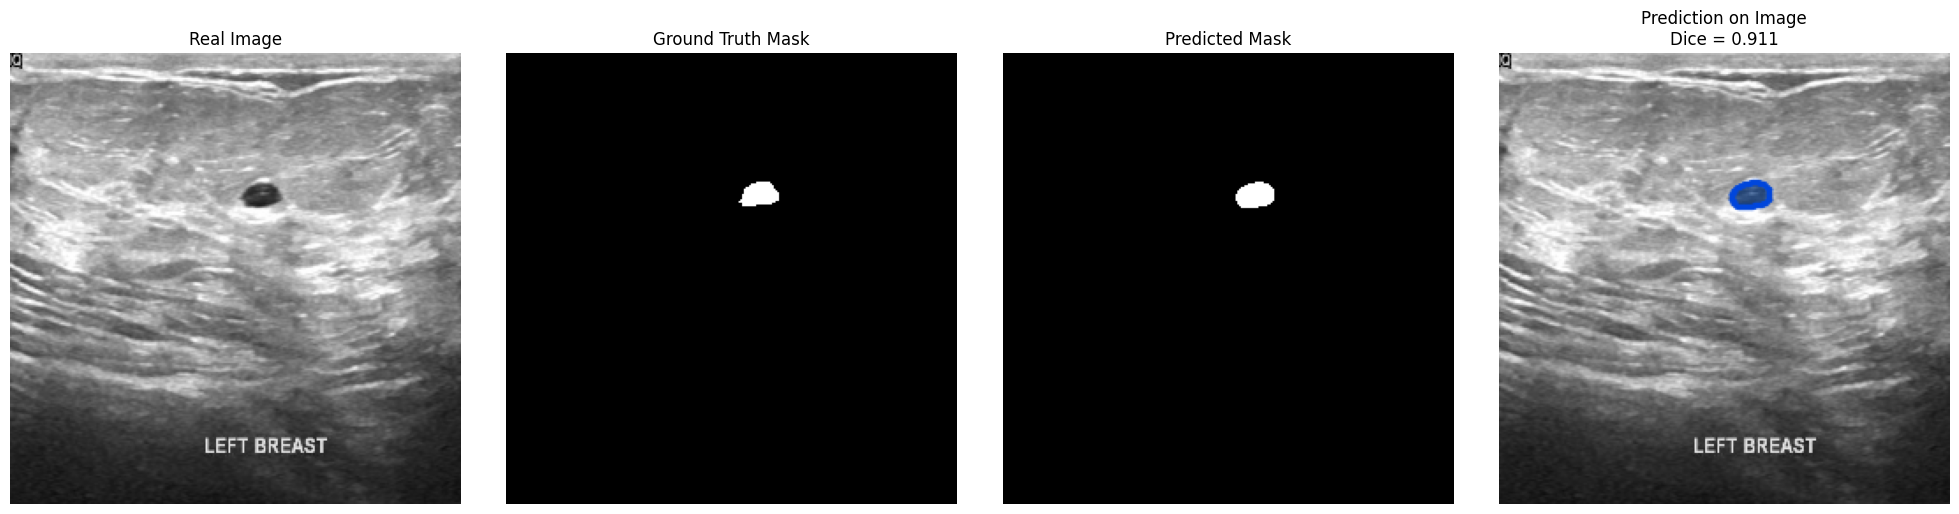


Visualization completed!
Image       : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png
GT Mask     : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png
Dice        : 0.9105

Saved files:
/kaggle/working/UNet/XAI/real_image.png
/kaggle/working/UNet/XAI/ground_truth_mask.png
/kaggle/working/UNet/XAI/predicted_mask.png
/kaggle/working/UNet/XAI/predicted_mask_on_image.png


In [21]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


IMAGE_PATH = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png"

MASK_DIR = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks"

SAVE_DIR = "/kaggle/working/UNet/XAI"
os.makedirs(SAVE_DIR, exist_ok=True)


THRESHOLD = 0.4

MASK_COLOR = np.array([30, 120, 255], dtype=np.uint8)

BORDER_COLOR = (0, 70, 220)

MASK_ALPHA = 0.35
BORDER_WIDTH = 2


image_filename = os.path.basename(IMAGE_PATH)

base_name = os.path.splitext(image_filename)[0]

mask_path = os.path.join(
    MASK_DIR,
    base_name + "_mask.png"
)

if not os.path.exists(mask_path):

    found_mask = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:

        temp_path = os.path.join(
            MASK_DIR,
            base_name + "_mask" + ext
        )

        if os.path.exists(temp_path):
            found_mask = temp_path
            break

    if found_mask is None:
        raise FileNotFoundError(
            f"Mask not found for:\n{IMAGE_PATH}\n\n"
            f"Expected mask similar to:\n"
            f"{base_name}_mask.png"
        )

    mask_path = found_mask


print("Image:")
print(IMAGE_PATH)

print("\nGround Truth Mask:")
print(mask_path)


original_pil = Image.open(IMAGE_PATH).convert("RGB")

original_image = np.array(original_pil)


gt_pil = Image.open(mask_path).convert("L")

gt_mask_original = np.array(gt_pil)

gt_mask_original = (
    gt_mask_original > 127
).astype(np.uint8)


model_input = image_transform(original_pil)

model_input = model_input.unsqueeze(0).to(device)


model.eval()

with torch.no_grad():

    output = model(model_input)

    if isinstance(output, (tuple, list)):
        output = output[0]

    probability = torch.sigmoid(output)

    predicted_mask = (
        probability > THRESHOLD
    ).long()


predicted_mask = predicted_mask.squeeze().cpu().numpy().astype(np.uint8)


output_h, output_w = predicted_mask.shape

gt_mask = cv2.resize(
    gt_mask_original,
    (output_w, output_h),
    interpolation=cv2.INTER_NEAREST
)

gt_mask = (
    gt_mask > 0
).astype(np.uint8)


display_image = cv2.resize(
    original_image,
    (output_w, output_h),
    interpolation=cv2.INTER_LINEAR
)

display_image = np.ascontiguousarray(
    display_image,
    dtype=np.uint8
)


gt_mask_display = (
    gt_mask * 255
).astype(np.uint8)


pred_mask_display = (
    predicted_mask * 255
).astype(np.uint8)


overlay = display_image.copy()

prediction_pixels = predicted_mask == 1

overlay[prediction_pixels] = (
    overlay[prediction_pixels].astype(np.float32)
    * (1 - MASK_ALPHA)
    +
    MASK_COLOR.astype(np.float32)
    * MASK_ALPHA
).astype(np.uint8)


contours, _ = cv2.findContours(
    predicted_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = np.ascontiguousarray(overlay)

cv2.drawContours(
    overlay,
    contours,
    -1,
    BORDER_COLOR,
    BORDER_WIDTH,
    lineType=cv2.LINE_AA
)


intersection = np.logical_and(
    predicted_mask == 1,
    gt_mask == 1
).sum()

pred_area = (
    predicted_mask == 1
).sum()

gt_area = (
    gt_mask == 1
).sum()

dice = (
    2.0 * intersection
    /
    (pred_area + gt_area + 1e-8)
)


save_path = os.path.join(
    SAVE_DIR,
    "real_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(display_image)

plt.title(
    "Real Image",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "ground_truth_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Ground Truth Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Predicted Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask_on_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(overlay)

plt.title(
    f"Predicted Mask on Image\nDice = {dice:.3f}",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(display_image)
axes[0].set_title("Real Image")

axes[1].imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1].set_title("Ground Truth Mask")

axes[2].imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("Predicted Mask")

axes[3].imshow(overlay)
axes[3].set_title(
    f"Prediction on Image\nDice = {dice:.3f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

plt.close()


print("\n" + "=" * 60)
print("Visualization completed!")
print("=" * 60)

print(f"Image       : {IMAGE_PATH}")
print(f"GT Mask     : {mask_path}")
print(f"Dice        : {dice:.4f}")

print("\nSaved files:")

print(
    os.path.join(
        SAVE_DIR,
        "real_image.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "ground_truth_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask_on_image.png"
    )

)

print("=" * 60)

# ResUNet

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity

        out = self.relu(out)

        return out


class ResUNet(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        features=[64, 128, 256, 512]
    ):
        super().__init__()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.encoder = nn.ModuleList()

        ch = in_channels

        for f in features:
            self.encoder.append(
                ResidualBlock(ch, f)
            )
            ch = f

        self.bottleneck = ResidualBlock(
            features[-1],
            features[-1] * 2
        )

        self.upconvs = nn.ModuleList()
        self.decoder = nn.ModuleList()

        for f in reversed(features):

            self.upconvs.append(
                nn.ConvTranspose2d(
                    f * 2,
                    f,
                    kernel_size=2,
                    stride=2
                )
            )

            self.decoder.append(
                ResidualBlock(
                    f * 2,
                    f
                )
            )

        self.segmentation_head = nn.Conv2d(
            features[0],
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        skips = []

        for encoder_block in self.encoder:

            x = encoder_block(x)

            skips.append(x)

            x = self.pool(x)

        x = self.bottleneck(x)

        skips = skips[::-1]

        for idx in range(len(self.upconvs)):

            x = self.upconvs[idx](x)

            skip = skips[idx]

            if x.shape[2:] != skip.shape[2:]:

                x = F.interpolate(
                    x,
                    size=skip.shape[2:],
                    mode="bilinear",
                    align_corners=False
                )

            x = torch.cat(
                (skip, x),
                dim=1
            )

            x = self.decoder[idx](x)

        logits = self.segmentation_head(x)

        return logits


model = ResUNet(
    in_channels=3,
    out_channels=1,
    features=[64, 128, 256, 512]
).to(device)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 32,436,353
Trainable parameters: 32,436,353


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = CombinedLoss().to(device)
num_epochs = 200
aux_weight = 0.6

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

def deep_supervision_loss(criterion, main_logits, aux_logits_list, masks, aux_weight=0.4):
    loss = criterion(main_logits, masks)
    for aux in aux_logits_list:
        loss = loss + aux_weight * criterion(aux, masks)
    return loss

class EarlyStopping:
    def __init__(self, patience=15, verbose=True):
        self.patience   = patience
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.stop       = False
    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), "best_model.pth")
            if self.verbose:
                print(f"  Val loss improved to {self.best_loss:.4f} — model saved.")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement. EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                print("  Early stopping triggered.")
                self.stop = True

early_stopping = EarlyStopping(patience=15, verbose=True)
train_losses, val_losses = [], []
train_dices, val_dices   = [], []
train_ious, val_ious     = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou  = 0.0

    for imgs, masks, labels in train_loader:
        imgs  = imgs.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(imgs)
        if isinstance(outputs, (list, tuple)):
            main_logits = outputs[0]
            aux_logits  = outputs[1:]
        else:
            main_logits = outputs
            aux_logits  = []

        loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(main_logits, masks).item()
        train_iou  += iou_score(main_logits, masks).item()

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou  = 0.0

    with torch.no_grad():
        for imgs, masks, labels in val_loader:
            imgs  = imgs.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)

            outputs = model(imgs)
            if isinstance(outputs, (list, tuple)):
                main_logits = outputs[0]
                aux_logits  = outputs[1:]
            else:
                main_logits = outputs
                aux_logits  = []

            loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

            val_loss += loss.item()
            val_dice += dice_score(main_logits, masks).item()
            val_iou  += iou_score(main_logits, masks).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice   = val_dice   / len(val_loader)
    avg_train_iou  = train_iou  / len(train_loader)
    avg_val_iou    = val_iou    / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)
    train_ious.append(avg_train_iou)
    val_ious.append(avg_val_iou)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Dice: {avg_val_dice:.4f} | "
          f"IoU: {avg_val_iou:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    scheduler.step()
    early_stopping(avg_val_loss, model)
    if early_stopping.stop:
        print(f"\nTraining stopped early at epoch {epoch+1}.")
        break

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
print("\nBest model loaded for evaluation.")

Epoch [1/200] Train Loss: 0.6834 | Val Loss: 0.8146 | Dice: 0.3372 | IoU: 0.2292 | LR: 3.00e-04
  ✅ Val loss improved to 0.8146 — model saved.
Epoch [2/200] Train Loss: 0.5700 | Val Loss: 0.5609 | Dice: 0.4688 | IoU: 0.3427 | LR: 3.00e-04
  ✅ Val loss improved to 0.5609 — model saved.
Epoch [3/200] Train Loss: 0.5156 | Val Loss: 0.5099 | Dice: 0.5764 | IoU: 0.4669 | LR: 3.00e-04
  ✅ Val loss improved to 0.5099 — model saved.
Epoch [4/200] Train Loss: 0.4697 | Val Loss: 0.4980 | Dice: 0.4921 | IoU: 0.3601 | LR: 3.00e-04
  ✅ Val loss improved to 0.4980 — model saved.
Epoch [5/200] Train Loss: 0.4322 | Val Loss: 0.4384 | Dice: 0.5585 | IoU: 0.4246 | LR: 3.00e-04
  ✅ Val loss improved to 0.4384 — model saved.
Epoch [6/200] Train Loss: 0.3860 | Val Loss: 0.3732 | Dice: 0.6616 | IoU: 0.5349 | LR: 3.00e-04
  ✅ Val loss improved to 0.3732 — model saved.
Epoch [7/200] Train Loss: 0.3513 | Val Loss: 0.3480 | Dice: 0.6639 | IoU: 0.5367 | LR: 2.99e-04
  ✅ Val loss improved to 0.3480 — model saved.

In [24]:
import torch
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt

def get_boundary(mask):
    mask = mask.astype(bool)
    return mask ^ binary_erosion(mask) if mask.any() else np.zeros_like(mask, dtype=bool)

def boundary_f1(pred, gt, tolerance=2):
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any(): return 0.0
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    precision = np.mean(gt_dist[pred_b] <= tolerance)
    recall = np.mean(pred_dist[gt_b] <= tolerance)
    return float(2 * precision * recall / (precision + recall + 1e-6))

def surface_distances(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() or not gt.any(): return np.nan, np.nan
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any(): return np.nan, np.nan
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    d_pred_gt, d_gt_pred = gt_dist[pred_b], pred_dist[gt_b]
    assd = (d_pred_gt.sum() + d_gt_pred.sum()) / (len(d_pred_gt) + len(d_gt_pred))
    hd95 = max(np.percentile(d_pred_gt, 95), np.percentile(d_gt_pred, 95))
    return float(assd), float(hd95)

def evaluate_segmentation(model, test_loader, device, threshold=0.4):
    model.eval().to(device)
    dice_all, iou_all, bf1_all, assd_all, hd95_all = [[], []], [[], []], [[], []], [[], []], [[], []]
    TP, FP, FN = [0, 0], [0, 0], [0, 0]
    total_correct = total_pixels = 0

    with torch.inference_mode():
        for imgs, masks, labels in test_loader:
            imgs = imgs.to(device, dtype=torch.float32, non_blocking=True)
            masks = masks.cpu()
            preds = (torch.sigmoid(model(imgs)) > threshold).squeeze(1).cpu()
            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()
            del imgs

            for b in range(preds.size(0)):
                pred = preds[b].numpy().astype(np.uint8)
                gt = masks[b].numpy().astype(np.uint8)

                for c in range(2):
                    p, g = pred == c, gt == c
                    inter = np.logical_and(p, g).sum()
                    p_sum, g_sum = p.sum(), g.sum()
                    union = p_sum + g_sum
                    dice_all[c].append((2 * inter + 1e-6) / (union + 1e-6))
                    iou_all[c].append((inter + 1e-6) / (union - inter + 1e-6))

                    TP[c] += int(np.logical_and(p, g).sum())
                    FP[c] += int(np.logical_and(p, ~g).sum())
                    FN[c] += int(np.logical_and(~p, g).sum())

                    bf1_all[c].append(boundary_f1(p, g, tolerance=2))
                    assd, hd95 = surface_distances(p, g)
                    if not np.isnan(assd):
                        assd_all[c].append(assd)
                        hd95_all[c].append(hd95)

            del preds, masks
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    precision, recall, f1 = [], [], []
    for c in range(2):
        p = TP[c] / (TP[c] + FP[c] + 1e-6)
        r = TP[c] / (TP[c] + FN[c] + 1e-6)
        precision.append(p)
        recall.append(r)
        f1.append(2 * p * r / (p + r + 1e-6))

    def mean(x): return float(np.mean(x)) if x else 0.0
    def std(x): return float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    names = ["Background", "Polyp"]
    print("\n==================== Test Set Metrics ====================")
    print(f"Overall Pixel Accuracy : {total_correct / (total_pixels + 1e-6):.4f}")
    print("----------------------------------------------------------")
    print(f"{'Class':<15}{'Dice':>8}{'IoU':>8}{'BF1':>8}{'ASSD':>9}{'HD95':>9}{'F1':>8}")
    print("----------------------------------------------------------")

    metrics = {}
    for c in range(2):
        d, i, b, a, h = map(mean, [dice_all[c], iou_all[c], bf1_all[c], assd_all[c], hd95_all[c]])
        metrics[c] = {"dice": d, "iou": i, "bf1": b, "assd": a, "hd95": h}
        print(f"{names[c]:<15}{d:8.4f}{i:8.4f}{b:8.4f}{a:9.2f}{h:9.2f}{f1[c]:8.4f}")

    mean_dice = np.mean([metrics[0]["dice"], metrics[1]["dice"]])
    mean_iou = np.mean([metrics[0]["iou"], metrics[1]["iou"]])
    mean_bf1 = np.mean([metrics[0]["bf1"], metrics[1]["bf1"]])
    mean_assd = np.mean([metrics[0]["assd"], metrics[1]["assd"]])
    mean_hd95 = np.mean([metrics[0]["hd95"], metrics[1]["hd95"]])
    mean_f1 = np.mean(f1)

    print("----------------------------------------------------------")
    print(f"{'Mean':<15}{mean_dice:8.4f}{mean_iou:8.4f}{mean_bf1:8.4f}{mean_assd:9.2f}{mean_hd95:9.2f}{mean_f1:8.4f}")
    print("==========================================================")

    accuracy = total_correct / (total_pixels + 1e-6)
    print("\n── Polyp Class (Primary Metrics) ──")
    print(f"Dice       : {metrics[1]['dice']:.4f}")
    print(f"IoU        : {metrics[1]['iou']:.4f}")
    print(f"Boundary F1: {metrics[1]['bf1']:.4f}")
    print(f"ASSD       : {metrics[1]['assd']:.2f}")
    print(f"HD95       : {metrics[1]['hd95']:.2f}")
    print(f"Precision  : {precision[1]:.4f}")
    print(f"Recall     : {recall[1]:.4f}")
    print(f"F1         : {f1[1]:.4f}")
    print("==========================================================\n")

    return {
        "accuracy": accuracy,
        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_boundary_f1": mean_bf1,
        "mean_assd": mean_assd,
        "mean_hd95": mean_hd95,
        "mean_f1": mean_f1,
        "polyp_dice": metrics[1]["dice"],
        "polyp_iou": metrics[1]["iou"],
        "polyp_boundary_f1": metrics[1]["bf1"],
        "polyp_assd": metrics[1]["assd"],
        "polyp_hd95": metrics[1]["hd95"],
        "polyp_precision": precision[1],
        "polyp_recall": recall[1],
        "polyp_f1": f1[1]
    }

results = evaluate_segmentation(model, test_loader, device=device, threshold=0.4)


==================== Test Set Metrics ====================
Overall Pixel Accuracy : 0.9525
----------------------------------------------------------
Class              Dice     IoU     BF1     ASSD     HD95      F1
----------------------------------------------------------
Background       0.9715  0.9475  0.8679     2.67    24.47  0.9739
Polyp            0.7027  0.6103  0.4061    15.27    40.99  0.7329
----------------------------------------------------------
Mean             0.8371  0.7789  0.6370     8.97    32.73  0.8534

── Polyp Class (Primary Metrics) ──
Dice       : 0.7027
IoU        : 0.6103
Boundary F1: 0.4061
ASSD       : 15.27
HD95       : 40.99
Precision  : 0.7620
Recall     : 0.7059
F1         : 0.7329



Image:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png

Ground Truth Mask:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png


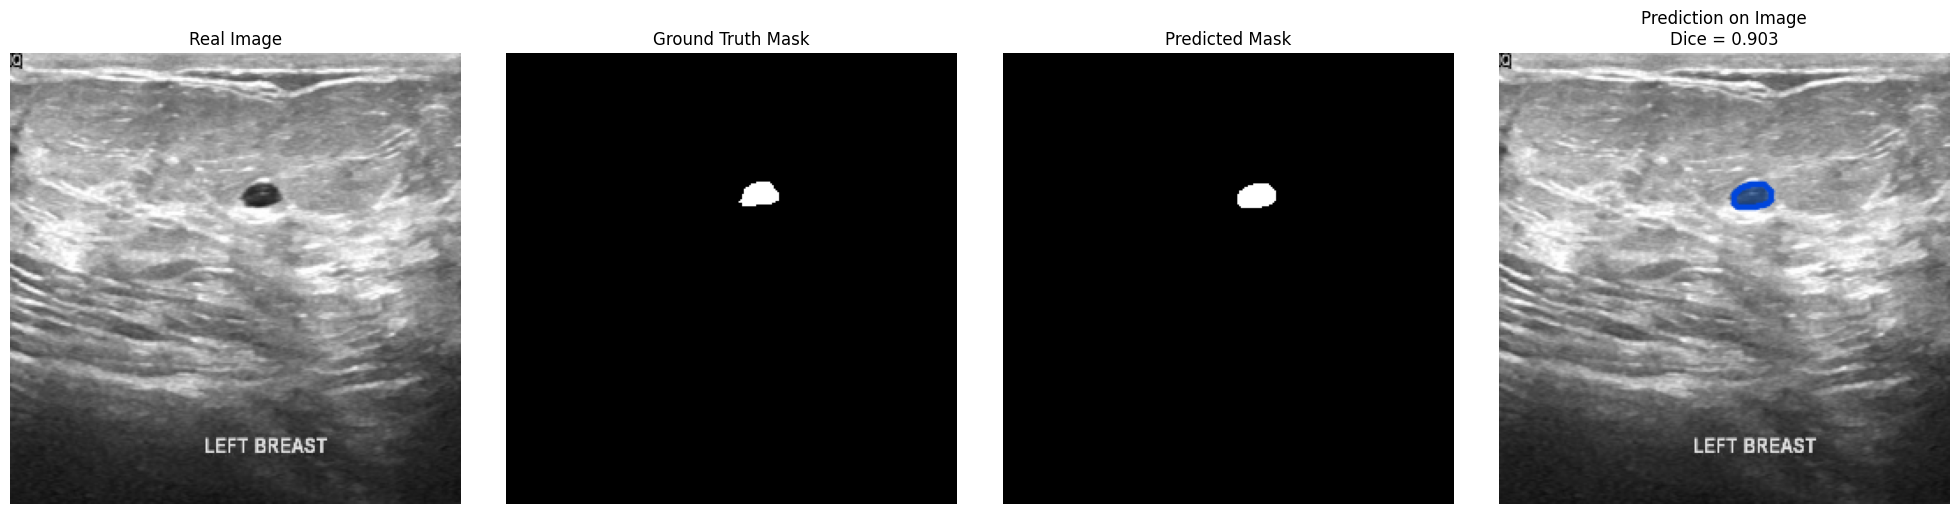


Visualization completed!
Image       : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png
GT Mask     : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png
Dice        : 0.9028

Saved files:
/kaggle/working/UNet/XAI/real_image.png
/kaggle/working/UNet/XAI/ground_truth_mask.png
/kaggle/working/UNet/XAI/predicted_mask.png
/kaggle/working/UNet/XAI/predicted_mask_on_image.png


In [25]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


IMAGE_PATH = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png"

MASK_DIR = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks"

SAVE_DIR = "/kaggle/working/UNet/XAI"
os.makedirs(SAVE_DIR, exist_ok=True)


THRESHOLD = 0.4

MASK_COLOR = np.array([30, 120, 255], dtype=np.uint8)

BORDER_COLOR = (0, 70, 220)

MASK_ALPHA = 0.35
BORDER_WIDTH = 2


image_filename = os.path.basename(IMAGE_PATH)

base_name = os.path.splitext(image_filename)[0]

mask_path = os.path.join(
    MASK_DIR,
    base_name + "_mask.png"
)

if not os.path.exists(mask_path):

    found_mask = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:

        temp_path = os.path.join(
            MASK_DIR,
            base_name + "_mask" + ext
        )

        if os.path.exists(temp_path):
            found_mask = temp_path
            break

    if found_mask is None:
        raise FileNotFoundError(
            f"Mask not found for:\n{IMAGE_PATH}\n\n"
            f"Expected mask similar to:\n"
            f"{base_name}_mask.png"
        )

    mask_path = found_mask


print("Image:")
print(IMAGE_PATH)

print("\nGround Truth Mask:")
print(mask_path)


original_pil = Image.open(IMAGE_PATH).convert("RGB")

original_image = np.array(original_pil)


gt_pil = Image.open(mask_path).convert("L")

gt_mask_original = np.array(gt_pil)

gt_mask_original = (
    gt_mask_original > 127
).astype(np.uint8)


model_input = image_transform(original_pil)

model_input = model_input.unsqueeze(0).to(device)


model.eval()

with torch.no_grad():

    output = model(model_input)

    if isinstance(output, (tuple, list)):
        output = output[0]

    probability = torch.sigmoid(output)

    predicted_mask = (
        probability > THRESHOLD
    ).long()


predicted_mask = predicted_mask.squeeze().cpu().numpy().astype(np.uint8)


output_h, output_w = predicted_mask.shape

gt_mask = cv2.resize(
    gt_mask_original,
    (output_w, output_h),
    interpolation=cv2.INTER_NEAREST
)

gt_mask = (
    gt_mask > 0
).astype(np.uint8)


display_image = cv2.resize(
    original_image,
    (output_w, output_h),
    interpolation=cv2.INTER_LINEAR
)

display_image = np.ascontiguousarray(
    display_image,
    dtype=np.uint8
)


gt_mask_display = (
    gt_mask * 255
).astype(np.uint8)


pred_mask_display = (
    predicted_mask * 255
).astype(np.uint8)


overlay = display_image.copy()

prediction_pixels = predicted_mask == 1

overlay[prediction_pixels] = (
    overlay[prediction_pixels].astype(np.float32)
    * (1 - MASK_ALPHA)
    +
    MASK_COLOR.astype(np.float32)
    * MASK_ALPHA
).astype(np.uint8)


contours, _ = cv2.findContours(
    predicted_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = np.ascontiguousarray(overlay)

cv2.drawContours(
    overlay,
    contours,
    -1,
    BORDER_COLOR,
    BORDER_WIDTH,
    lineType=cv2.LINE_AA
)


intersection = np.logical_and(
    predicted_mask == 1,
    gt_mask == 1
).sum()

pred_area = (
    predicted_mask == 1
).sum()

gt_area = (
    gt_mask == 1
).sum()

dice = (
    2.0 * intersection
    /
    (pred_area + gt_area + 1e-8)
)


save_path = os.path.join(
    SAVE_DIR,
    "real_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(display_image)

plt.title(
    "Real Image",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "ground_truth_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Ground Truth Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Predicted Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask_on_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(overlay)

plt.title(
    f"Predicted Mask on Image\nDice = {dice:.3f}",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(display_image)
axes[0].set_title("Real Image")

axes[1].imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1].set_title("Ground Truth Mask")

axes[2].imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("Predicted Mask")

axes[3].imshow(overlay)
axes[3].set_title(
    f"Prediction on Image\nDice = {dice:.3f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

plt.close()


print("\n" + "=" * 60)
print("Visualization completed!")
print("=" * 60)

print(f"Image       : {IMAGE_PATH}")
print(f"GT Mask     : {mask_path}")
print(f"Dice        : {dice:.4f}")

print("\nSaved files:")

print(
    os.path.join(
        SAVE_DIR,
        "real_image.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "ground_truth_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask_on_image.png"
    )

)

print("=" * 60)

# AttentionUNet

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):

    def __init__(
        self,
        gating_channels,
        skip_channels,
        inter_channels
    ):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(
                gating_channels,
                inter_channels,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(inter_channels)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(
                skip_channels,
                inter_channels,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(inter_channels)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(
                inter_channels,
                1,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=True
            ),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):

        g1 = self.W_g(g)

        x1 = self.W_x(x)

        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(
                g1,
                size=x1.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        psi = self.relu(g1 + x1)

        psi = self.psi(psi)

        return x * psi


class AttentionUNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        features=[64, 128, 256, 512]
    ):
        super().__init__()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.encoder1 = DoubleConv(
            in_channels,
            features[0]
        )

        self.encoder2 = DoubleConv(
            features[0],
            features[1]
        )

        self.encoder3 = DoubleConv(
            features[1],
            features[2]
        )

        self.encoder4 = DoubleConv(
            features[2],
            features[3]
        )

        self.bottleneck = DoubleConv(
            features[3],
            features[3] * 2
        )

        self.upconv4 = nn.ConvTranspose2d(
            features[3] * 2,
            features[3],
            kernel_size=2,
            stride=2
        )

        self.attention4 = AttentionGate(
            gating_channels=features[3],
            skip_channels=features[3],
            inter_channels=features[3] // 2
        )

        self.decoder4 = DoubleConv(
            features[3] * 2,
            features[3]
        )

        self.upconv3 = nn.ConvTranspose2d(
            features[3],
            features[2],
            kernel_size=2,
            stride=2
        )

        self.attention3 = AttentionGate(
            gating_channels=features[2],
            skip_channels=features[2],
            inter_channels=features[2] // 2
        )

        self.decoder3 = DoubleConv(
            features[2] * 2,
            features[2]
        )

        self.upconv2 = nn.ConvTranspose2d(
            features[2],
            features[1],
            kernel_size=2,
            stride=2
        )

        self.attention2 = AttentionGate(
            gating_channels=features[1],
            skip_channels=features[1],
            inter_channels=features[1] // 2
        )

        self.decoder2 = DoubleConv(
            features[1] * 2,
            features[1]
        )

        self.upconv1 = nn.ConvTranspose2d(
            features[1],
            features[0],
            kernel_size=2,
            stride=2
        )

        self.attention1 = AttentionGate(
            gating_channels=features[0],
            skip_channels=features[0],
            inter_channels=features[0] // 2
        )

        self.decoder1 = DoubleConv(
            features[0] * 2,
            features[0]
        )

        self.segmentation_head = nn.Conv2d(
            features[0],
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        input_size = x.shape[2:]

        enc1 = self.encoder1(x)
        pool1 = self.pool(enc1)

        enc2 = self.encoder2(pool1)
        pool2 = self.pool(enc2)

        enc3 = self.encoder3(pool2)
        pool3 = self.pool(enc3)

        enc4 = self.encoder4(pool3)
        pool4 = self.pool(enc4)

        bottleneck = self.bottleneck(pool4)

        dec4 = self.upconv4(bottleneck)

        if dec4.shape[2:] != enc4.shape[2:]:
            dec4 = F.interpolate(
                dec4,
                size=enc4.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        att4 = self.attention4(
            enc4,
            dec4
        )

        dec4 = torch.cat(
            [att4, dec4],
            dim=1
        )

        dec4 = self.decoder4(dec4)

        dec3 = self.upconv3(dec4)

        if dec3.shape[2:] != enc3.shape[2:]:
            dec3 = F.interpolate(
                dec3,
                size=enc3.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        att3 = self.attention3(
            enc3,
            dec3
        )

        dec3 = torch.cat(
            [att3, dec3],
            dim=1
        )

        dec3 = self.decoder3(dec3)

        dec2 = self.upconv2(dec3)

        if dec2.shape[2:] != enc2.shape[2:]:
            dec2 = F.interpolate(
                dec2,
                size=enc2.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        att2 = self.attention2(
            enc2,
            dec2
        )

        dec2 = torch.cat(
            [att2, dec2],
            dim=1
        )

        dec2 = self.decoder2(dec2)

        dec1 = self.upconv1(dec2)

        if dec1.shape[2:] != enc1.shape[2:]:
            dec1 = F.interpolate(
                dec1,
                size=enc1.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        att1 = self.attention1(
            enc1,
            dec1
        )

        dec1 = torch.cat(
            [att1, dec1],
            dim=1
        )

        dec1 = self.decoder1(dec1)

        logits = self.segmentation_head(dec1)

        if logits.shape[2:] != input_size:
            logits = F.interpolate(
                logits,
                size=input_size,
                mode="bilinear",
                align_corners=False
            )

        return logits


model = AttentionUNet(
    in_channels=3,
    out_channels=1,
    features=[64, 128, 256, 512]
).to(device)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("Attention U-Net")
print("=" * 60)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("=" * 60)


x = torch.randn(
    1,
    3,
    256,
    256
).to(device)

with torch.no_grad():
    logits = model(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {logits.shape}")

print("=" * 60)

Attention U-Net
Total parameters:     31,388,205
Trainable parameters: 31,388,205
Input shape:  torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = CombinedLoss().to(device)
num_epochs = 200
aux_weight = 0.6

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

def deep_supervision_loss(criterion, main_logits, aux_logits_list, masks, aux_weight=0.4):
    loss = criterion(main_logits, masks)
    for aux in aux_logits_list:
        loss = loss + aux_weight * criterion(aux, masks)
    return loss

class EarlyStopping:
    def __init__(self, patience=15, verbose=True):
        self.patience   = patience
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.stop       = False
    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), "best_model.pth")
            if self.verbose:
                print(f"  Val loss improved to {self.best_loss:.4f} — model saved.")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement. EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                print("  Early stopping triggered.")
                self.stop = True

early_stopping = EarlyStopping(patience=15, verbose=True)
train_losses, val_losses = [], []
train_dices, val_dices   = [], []
train_ious, val_ious     = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou  = 0.0

    for imgs, masks, labels in train_loader:
        imgs  = imgs.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(imgs)
        if isinstance(outputs, (list, tuple)):
            main_logits = outputs[0]
            aux_logits  = outputs[1:]
        else:
            main_logits = outputs
            aux_logits  = []

        loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(main_logits, masks).item()
        train_iou  += iou_score(main_logits, masks).item()

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou  = 0.0

    with torch.no_grad():
        for imgs, masks, labels in val_loader:
            imgs  = imgs.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)

            outputs = model(imgs)
            if isinstance(outputs, (list, tuple)):
                main_logits = outputs[0]
                aux_logits  = outputs[1:]
            else:
                main_logits = outputs
                aux_logits  = []

            loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

            val_loss += loss.item()
            val_dice += dice_score(main_logits, masks).item()
            val_iou  += iou_score(main_logits, masks).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice   = val_dice   / len(val_loader)
    avg_train_iou  = train_iou  / len(train_loader)
    avg_val_iou    = val_iou    / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)
    train_ious.append(avg_train_iou)
    val_ious.append(avg_val_iou)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Dice: {avg_val_dice:.4f} | "
          f"IoU: {avg_val_iou:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    scheduler.step()
    early_stopping(avg_val_loss, model)
    if early_stopping.stop:
        print(f"\nTraining stopped early at epoch {epoch+1}.")
        break

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
print("\nBest model loaded for evaluation.")

Epoch [1/200] Train Loss: 0.7188 | Val Loss: 0.6404 | Dice: 0.4033 | IoU: 0.2866 | LR: 3.00e-04
  ✅ Val loss improved to 0.6404 — model saved.
Epoch [2/200] Train Loss: 0.6378 | Val Loss: 0.8883 | Dice: 0.2987 | IoU: 0.2009 | LR: 3.00e-04
  ⚠️ No improvement. EarlyStopping counter: 1/15
Epoch [3/200] Train Loss: 0.5965 | Val Loss: 0.5882 | Dice: 0.5497 | IoU: 0.4236 | LR: 3.00e-04
  ✅ Val loss improved to 0.5882 — model saved.
Epoch [4/200] Train Loss: 0.5516 | Val Loss: 0.5372 | Dice: 0.5158 | IoU: 0.3923 | LR: 3.00e-04
  ✅ Val loss improved to 0.5372 — model saved.
Epoch [5/200] Train Loss: 0.5135 | Val Loss: 0.6198 | Dice: 0.4116 | IoU: 0.2957 | LR: 3.00e-04
  ⚠️ No improvement. EarlyStopping counter: 1/15
Epoch [6/200] Train Loss: 0.4893 | Val Loss: 0.5412 | Dice: 0.4906 | IoU: 0.3689 | LR: 3.00e-04
  ⚠️ No improvement. EarlyStopping counter: 2/15
Epoch [7/200] Train Loss: 0.4457 | Val Loss: 0.4752 | Dice: 0.5249 | IoU: 0.3972 | LR: 2.99e-04
  ✅ Val loss improved to 0.4752 — model 

In [28]:
import torch
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt

def get_boundary(mask):
    mask = mask.astype(bool)
    return mask ^ binary_erosion(mask) if mask.any() else np.zeros_like(mask, dtype=bool)

def boundary_f1(pred, gt, tolerance=2):
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any(): return 0.0
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    precision = np.mean(gt_dist[pred_b] <= tolerance)
    recall = np.mean(pred_dist[gt_b] <= tolerance)
    return float(2 * precision * recall / (precision + recall + 1e-6))

def surface_distances(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() or not gt.any(): return np.nan, np.nan
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any(): return np.nan, np.nan
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    d_pred_gt, d_gt_pred = gt_dist[pred_b], pred_dist[gt_b]
    assd = (d_pred_gt.sum() + d_gt_pred.sum()) / (len(d_pred_gt) + len(d_gt_pred))
    hd95 = max(np.percentile(d_pred_gt, 95), np.percentile(d_gt_pred, 95))
    return float(assd), float(hd95)

def evaluate_segmentation(model, test_loader, device, threshold=0.4):
    model.eval().to(device)
    dice_all, iou_all, bf1_all, assd_all, hd95_all = [[], []], [[], []], [[], []], [[], []], [[], []]
    TP, FP, FN = [0, 0], [0, 0], [0, 0]
    total_correct = total_pixels = 0

    with torch.inference_mode():
        for imgs, masks, labels in test_loader:
            imgs = imgs.to(device, dtype=torch.float32, non_blocking=True)
            masks = masks.cpu()
            preds = (torch.sigmoid(model(imgs)) > threshold).squeeze(1).cpu()
            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()
            del imgs

            for b in range(preds.size(0)):
                pred = preds[b].numpy().astype(np.uint8)
                gt = masks[b].numpy().astype(np.uint8)

                for c in range(2):
                    p, g = pred == c, gt == c
                    inter = np.logical_and(p, g).sum()
                    p_sum, g_sum = p.sum(), g.sum()
                    union = p_sum + g_sum
                    dice_all[c].append((2 * inter + 1e-6) / (union + 1e-6))
                    iou_all[c].append((inter + 1e-6) / (union - inter + 1e-6))

                    TP[c] += int(np.logical_and(p, g).sum())
                    FP[c] += int(np.logical_and(p, ~g).sum())
                    FN[c] += int(np.logical_and(~p, g).sum())

                    bf1_all[c].append(boundary_f1(p, g, tolerance=2))
                    assd, hd95 = surface_distances(p, g)
                    if not np.isnan(assd):
                        assd_all[c].append(assd)
                        hd95_all[c].append(hd95)

            del preds, masks
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    precision, recall, f1 = [], [], []
    for c in range(2):
        p = TP[c] / (TP[c] + FP[c] + 1e-6)
        r = TP[c] / (TP[c] + FN[c] + 1e-6)
        precision.append(p)
        recall.append(r)
        f1.append(2 * p * r / (p + r + 1e-6))

    def mean(x): return float(np.mean(x)) if x else 0.0
    def std(x): return float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    names = ["Background", "Polyp"]
    print("\n==================== Test Set Metrics ====================")
    print(f"Overall Pixel Accuracy : {total_correct / (total_pixels + 1e-6):.4f}")
    print("----------------------------------------------------------")
    print(f"{'Class':<15}{'Dice':>8}{'IoU':>8}{'BF1':>8}{'ASSD':>9}{'HD95':>9}{'F1':>8}")
    print("----------------------------------------------------------")

    metrics = {}
    for c in range(2):
        d, i, b, a, h = map(mean, [dice_all[c], iou_all[c], bf1_all[c], assd_all[c], hd95_all[c]])
        metrics[c] = {"dice": d, "iou": i, "bf1": b, "assd": a, "hd95": h}
        print(f"{names[c]:<15}{d:8.4f}{i:8.4f}{b:8.4f}{a:9.2f}{h:9.2f}{f1[c]:8.4f}")

    mean_dice = np.mean([metrics[0]["dice"], metrics[1]["dice"]])
    mean_iou = np.mean([metrics[0]["iou"], metrics[1]["iou"]])
    mean_bf1 = np.mean([metrics[0]["bf1"], metrics[1]["bf1"]])
    mean_assd = np.mean([metrics[0]["assd"], metrics[1]["assd"]])
    mean_hd95 = np.mean([metrics[0]["hd95"], metrics[1]["hd95"]])
    mean_f1 = np.mean(f1)

    print("----------------------------------------------------------")
    print(f"{'Mean':<15}{mean_dice:8.4f}{mean_iou:8.4f}{mean_bf1:8.4f}{mean_assd:9.2f}{mean_hd95:9.2f}{mean_f1:8.4f}")
    print("==========================================================")

    accuracy = total_correct / (total_pixels + 1e-6)
    print("\n── Polyp Class (Primary Metrics) ──")
    print(f"Dice       : {metrics[1]['dice']:.4f}")
    print(f"IoU        : {metrics[1]['iou']:.4f}")
    print(f"Boundary F1: {metrics[1]['bf1']:.4f}")
    print(f"ASSD       : {metrics[1]['assd']:.2f}")
    print(f"HD95       : {metrics[1]['hd95']:.2f}")
    print(f"Precision  : {precision[1]:.4f}")
    print(f"Recall     : {recall[1]:.4f}")
    print(f"F1         : {f1[1]:.4f}")
    print("==========================================================\n")

    return {
        "accuracy": accuracy,
        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_boundary_f1": mean_bf1,
        "mean_assd": mean_assd,
        "mean_hd95": mean_hd95,
        "mean_f1": mean_f1,
        "polyp_dice": metrics[1]["dice"],
        "polyp_iou": metrics[1]["iou"],
        "polyp_boundary_f1": metrics[1]["bf1"],
        "polyp_assd": metrics[1]["assd"],
        "polyp_hd95": metrics[1]["hd95"],
        "polyp_precision": precision[1],
        "polyp_recall": recall[1],
        "polyp_f1": f1[1]
    }

results = evaluate_segmentation(model, test_loader, device=device, threshold=0.4)


==================== Test Set Metrics ====================
Overall Pixel Accuracy : 0.9530
----------------------------------------------------------
Class              Dice     IoU     BF1     ASSD     HD95      F1
----------------------------------------------------------
Background       0.9720  0.9480  0.8653     2.65    21.95  0.9742
Polyp            0.7222  0.6245  0.4311    14.34    40.02  0.7399
----------------------------------------------------------
Mean             0.8471  0.7862  0.6482     8.50    30.98  0.8570

── Polyp Class (Primary Metrics) ──
Dice       : 0.7222
IoU        : 0.6245
Boundary F1: 0.4311
ASSD       : 14.34
HD95       : 40.02
Precision  : 0.7565
Recall     : 0.7239
F1         : 0.7399



Image:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png

Ground Truth Mask:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png


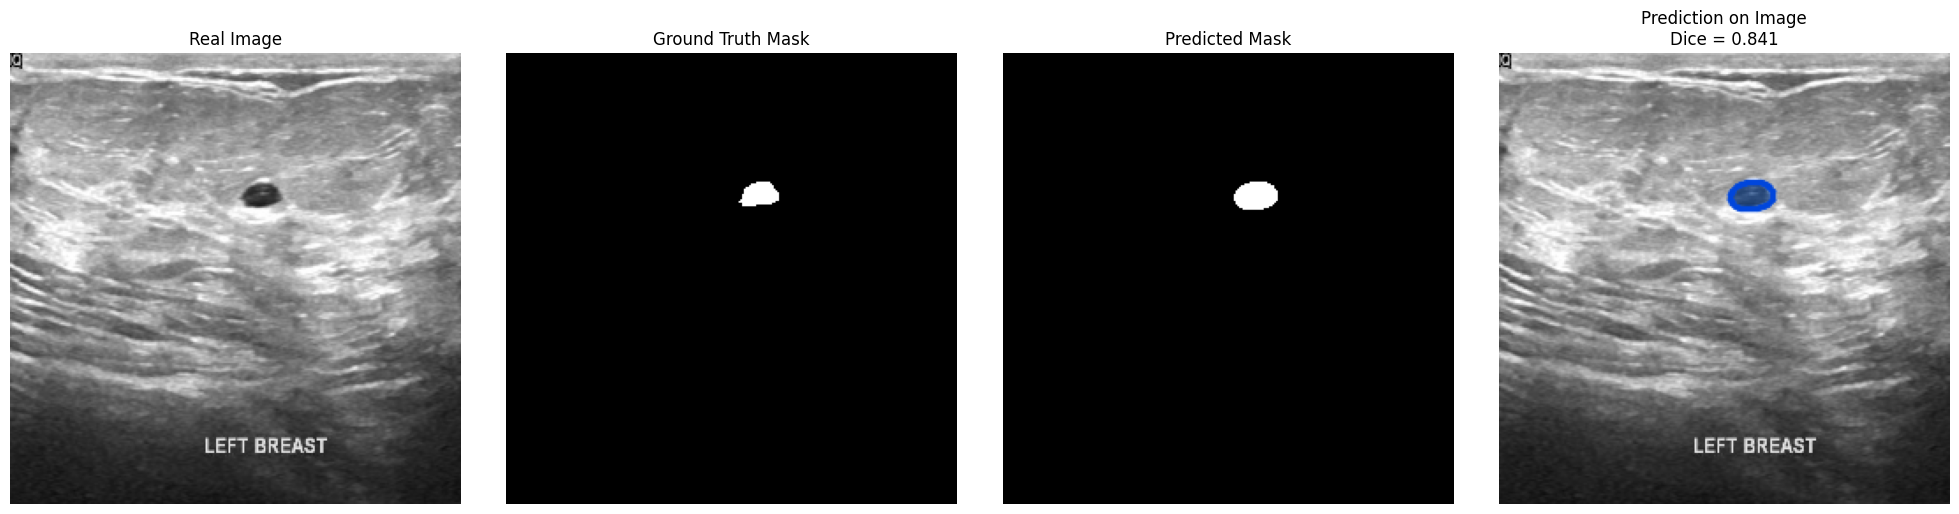


Visualization completed!
Image       : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png
GT Mask     : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png
Dice        : 0.8410

Saved files:
/kaggle/working/UNet/XAI/real_image.png
/kaggle/working/UNet/XAI/ground_truth_mask.png
/kaggle/working/UNet/XAI/predicted_mask.png
/kaggle/working/UNet/XAI/predicted_mask_on_image.png


In [29]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


IMAGE_PATH = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png"

MASK_DIR = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks"

SAVE_DIR = "/kaggle/working/UNet/XAI"
os.makedirs(SAVE_DIR, exist_ok=True)


THRESHOLD = 0.4

MASK_COLOR = np.array([30, 120, 255], dtype=np.uint8)

BORDER_COLOR = (0, 70, 220)

MASK_ALPHA = 0.35
BORDER_WIDTH = 2


image_filename = os.path.basename(IMAGE_PATH)

base_name = os.path.splitext(image_filename)[0]

mask_path = os.path.join(
    MASK_DIR,
    base_name + "_mask.png"
)

if not os.path.exists(mask_path):

    found_mask = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:

        temp_path = os.path.join(
            MASK_DIR,
            base_name + "_mask" + ext
        )

        if os.path.exists(temp_path):
            found_mask = temp_path
            break

    if found_mask is None:
        raise FileNotFoundError(
            f"Mask not found for:\n{IMAGE_PATH}\n\n"
            f"Expected mask similar to:\n"
            f"{base_name}_mask.png"
        )

    mask_path = found_mask


print("Image:")
print(IMAGE_PATH)

print("\nGround Truth Mask:")
print(mask_path)


original_pil = Image.open(IMAGE_PATH).convert("RGB")

original_image = np.array(original_pil)


gt_pil = Image.open(mask_path).convert("L")

gt_mask_original = np.array(gt_pil)

gt_mask_original = (
    gt_mask_original > 127
).astype(np.uint8)


model_input = image_transform(original_pil)

model_input = model_input.unsqueeze(0).to(device)


model.eval()

with torch.no_grad():

    output = model(model_input)

    if isinstance(output, (tuple, list)):
        output = output[0]

    probability = torch.sigmoid(output)

    predicted_mask = (
        probability > THRESHOLD
    ).long()


predicted_mask = predicted_mask.squeeze().cpu().numpy().astype(np.uint8)


output_h, output_w = predicted_mask.shape

gt_mask = cv2.resize(
    gt_mask_original,
    (output_w, output_h),
    interpolation=cv2.INTER_NEAREST
)

gt_mask = (
    gt_mask > 0
).astype(np.uint8)


display_image = cv2.resize(
    original_image,
    (output_w, output_h),
    interpolation=cv2.INTER_LINEAR
)

display_image = np.ascontiguousarray(
    display_image,
    dtype=np.uint8
)


gt_mask_display = (
    gt_mask * 255
).astype(np.uint8)


pred_mask_display = (
    predicted_mask * 255
).astype(np.uint8)


overlay = display_image.copy()

prediction_pixels = predicted_mask == 1

overlay[prediction_pixels] = (
    overlay[prediction_pixels].astype(np.float32)
    * (1 - MASK_ALPHA)
    +
    MASK_COLOR.astype(np.float32)
    * MASK_ALPHA
).astype(np.uint8)


contours, _ = cv2.findContours(
    predicted_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = np.ascontiguousarray(overlay)

cv2.drawContours(
    overlay,
    contours,
    -1,
    BORDER_COLOR,
    BORDER_WIDTH,
    lineType=cv2.LINE_AA
)


intersection = np.logical_and(
    predicted_mask == 1,
    gt_mask == 1
).sum()

pred_area = (
    predicted_mask == 1
).sum()

gt_area = (
    gt_mask == 1
).sum()

dice = (
    2.0 * intersection
    /
    (pred_area + gt_area + 1e-8)
)


save_path = os.path.join(
    SAVE_DIR,
    "real_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(display_image)

plt.title(
    "Real Image",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "ground_truth_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Ground Truth Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Predicted Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask_on_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(overlay)

plt.title(
    f"Predicted Mask on Image\nDice = {dice:.3f}",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(display_image)
axes[0].set_title("Real Image")

axes[1].imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1].set_title("Ground Truth Mask")

axes[2].imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("Predicted Mask")

axes[3].imshow(overlay)
axes[3].set_title(
    f"Prediction on Image\nDice = {dice:.3f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

plt.close()


print("\n" + "=" * 60)
print("Visualization completed!")
print("=" * 60)

print(f"Image       : {IMAGE_PATH}")
print(f"GT Mask     : {mask_path}")
print(f"Dice        : {dice:.4f}")

print("\nSaved files:")

print(
    os.path.join(
        SAVE_DIR,
        "real_image.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "ground_truth_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask_on_image.png"
    )

)

print("=" * 60)

# UNeXt

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):
        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )

        self._init_weights()

    def _init_weights(self):

        for m in self.modules():

            if isinstance(
                m,
                nn.Conv2d
            ):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):

        return self.block(x)


class TokenMixer(nn.Module):

    def __init__(
        self,
        channels,
        expansion=4
    ):
        super().__init__()

        hidden_channels = channels * expansion

        self.block = nn.Sequential(

            nn.Conv2d(
                channels,
                hidden_channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(
                hidden_channels
            ),

            nn.GELU(),

            nn.Conv2d(
                hidden_channels,
                hidden_channels,
                kernel_size=3,
                padding=1,
                groups=hidden_channels,
                bias=False
            ),

            nn.BatchNorm2d(
                hidden_channels
            ),

            nn.GELU(),

            nn.Conv2d(
                hidden_channels,
                channels,
                kernel_size=1,
                bias=False
            ),

            nn.BatchNorm2d(
                channels
            )
        )

        self._init_weights()

    def _init_weights(self):

        for m in self.modules():

            if isinstance(
                m,
                nn.Conv2d
            ):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

    def forward(self, x):

        identity = x

        x = self.block(x)

        x = x + identity

        return x


class UNeXtBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):
        super().__init__()

        self.conv = ConvBlock(
            in_channels,
            out_channels
        )

        self.token_mixer = TokenMixer(
            out_channels,
            expansion=2
        )

    def forward(self, x):

        x = self.conv(x)

        x = self.token_mixer(x)

        return x


class DecoderBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):
        super().__init__()

        self.conv = ConvBlock(
            in_channels + skip_channels,
            out_channels
        )

    def forward(
        self,
        x,
        skip
    ):

        x = F.interpolate(
            x,
            size=skip.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.conv(x)

        return x


class UNeXt(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1,
        features=(32, 64, 128, 256)
    ):
        super().__init__()

        f1, f2, f3, f4 = features

        self.encoder1 = UNeXtBlock(
            in_channels,
            f1
        )

        self.encoder2 = UNeXtBlock(
            f1,
            f2
        )

        self.encoder3 = UNeXtBlock(
            f2,
            f3
        )

        self.bottleneck = UNeXtBlock(
            f3,
            f4
        )

        self.decoder3 = DecoderBlock(
            f4,
            f3,
            f3
        )

        self.decoder2 = DecoderBlock(
            f3,
            f2,
            f2
        )

        self.decoder1 = DecoderBlock(
            f2,
            f1,
            f1
        )

        self.segmentation_head = nn.Conv2d(
            f1,
            out_channels,
            kernel_size=1
        )

        self._init_weights()

    def _init_weights(self):

        for m in self.modules():

            if isinstance(
                m,
                nn.Conv2d
            ):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

            elif isinstance(
                m,
                nn.BatchNorm2d
            ):

                nn.init.constant_(
                    m.weight,
                    1
                )

                nn.init.constant_(
                    m.bias,
                    0
                )

    def forward(self, x):

        input_size = x.shape[2:]

        enc1 = self.encoder1(x)

        x = F.max_pool2d(
            enc1,
            kernel_size=2,
            stride=2
        )

        enc2 = self.encoder2(x)

        x = F.max_pool2d(
            enc2,
            kernel_size=2,
            stride=2
        )

        enc3 = self.encoder3(x)

        x = F.max_pool2d(
            enc3,
            kernel_size=2,
            stride=2
        )

        x = self.bottleneck(x)

        x = self.decoder3(
            x,
            enc3
        )

        x = self.decoder2(
            x,
            enc2
        )

        x = self.decoder1(
            x,
            enc1
        )

        logits = self.segmentation_head(x)

        if logits.shape[2:] != input_size:

            logits = F.interpolate(
                logits,
                size=input_size,
                mode="bilinear",
                align_corners=False
            )

        return logits


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = UNeXt(
    in_channels=3,
    out_channels=1,
    features=(32, 64, 128, 256)
).to(device)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("UNeXt Baseline")
print("=" * 60)

print(
    f"Total parameters:     {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

print(
    f"Parameters (M):       "
    f"{trainable_params / 1e6:.3f} M"
)

print("=" * 60)


x = torch.randn(
    2,
    3,
    256,
    256
).to(device)

with torch.no_grad():

    logits = model(x)

print(
    f"Input shape:  {x.shape}"
)

print(
    f"Output shape: {logits.shape}"
)

print("=" * 60)

UNeXt Baseline
Total parameters:     2,309,889
Trainable parameters: 2,309,889
Parameters (M):       2.310 M
Input shape:  torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = CombinedLoss().to(device)
num_epochs = 200
aux_weight = 0.6

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

def deep_supervision_loss(criterion, main_logits, aux_logits_list, masks, aux_weight=0.4):
    loss = criterion(main_logits, masks)
    for aux in aux_logits_list:
        loss = loss + aux_weight * criterion(aux, masks)
    return loss

class EarlyStopping:
    def __init__(self, patience=15, verbose=True):
        self.patience   = patience
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.stop       = False
    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), "best_model.pth")
            if self.verbose:
                print(f"  Val loss improved to {self.best_loss:.4f} — model saved.")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement. EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                print("  Early stopping triggered.")
                self.stop = True

early_stopping = EarlyStopping(patience=15, verbose=True)
train_losses, val_losses = [], []
train_dices, val_dices   = [], []
train_ious, val_ious     = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou  = 0.0

    for imgs, masks, labels in train_loader:
        imgs  = imgs.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(imgs)
        if isinstance(outputs, (list, tuple)):
            main_logits = outputs[0]
            aux_logits  = outputs[1:]
        else:
            main_logits = outputs
            aux_logits  = []

        loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(main_logits, masks).item()
        train_iou  += iou_score(main_logits, masks).item()

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou  = 0.0

    with torch.no_grad():
        for imgs, masks, labels in val_loader:
            imgs  = imgs.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)

            outputs = model(imgs)
            if isinstance(outputs, (list, tuple)):
                main_logits = outputs[0]
                aux_logits  = outputs[1:]
            else:
                main_logits = outputs
                aux_logits  = []

            loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

            val_loss += loss.item()
            val_dice += dice_score(main_logits, masks).item()
            val_iou  += iou_score(main_logits, masks).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice   = val_dice   / len(val_loader)
    avg_train_iou  = train_iou  / len(train_loader)
    avg_val_iou    = val_iou    / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)
    train_ious.append(avg_train_iou)
    val_ious.append(avg_val_iou)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Dice: {avg_val_dice:.4f} | "
          f"IoU: {avg_val_iou:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    scheduler.step()
    early_stopping(avg_val_loss, model)
    if early_stopping.stop:
        print(f"\nTraining stopped early at epoch {epoch+1}.")
        break

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
print("\nBest model loaded for evaluation.")

Epoch [1/200] Train Loss: 0.9685 | Val Loss: 0.7547 | Dice: 0.0505 | IoU: 0.0265 | LR: 3.00e-04
  ✅ Val loss improved to 0.7547 — model saved.
Epoch [2/200] Train Loss: 0.5948 | Val Loss: 0.6182 | Dice: 0.3705 | IoU: 0.2816 | LR: 3.00e-04
  ✅ Val loss improved to 0.6182 — model saved.
Epoch [3/200] Train Loss: 0.4830 | Val Loss: 0.5268 | Dice: 0.4579 | IoU: 0.3337 | LR: 3.00e-04
  ✅ Val loss improved to 0.5268 — model saved.
Epoch [4/200] Train Loss: 0.4587 | Val Loss: 0.4666 | Dice: 0.5378 | IoU: 0.4138 | LR: 3.00e-04
  ✅ Val loss improved to 0.4666 — model saved.
Epoch [5/200] Train Loss: 0.4382 | Val Loss: 0.4521 | Dice: 0.5325 | IoU: 0.4052 | LR: 3.00e-04
  ✅ Val loss improved to 0.4521 — model saved.
Epoch [6/200] Train Loss: 0.4027 | Val Loss: 0.4028 | Dice: 0.5867 | IoU: 0.4536 | LR: 3.00e-04
  ✅ Val loss improved to 0.4028 — model saved.
Epoch [7/200] Train Loss: 0.3618 | Val Loss: 0.3989 | Dice: 0.5906 | IoU: 0.4647 | LR: 2.99e-04
  ✅ Val loss improved to 0.3989 — model saved.

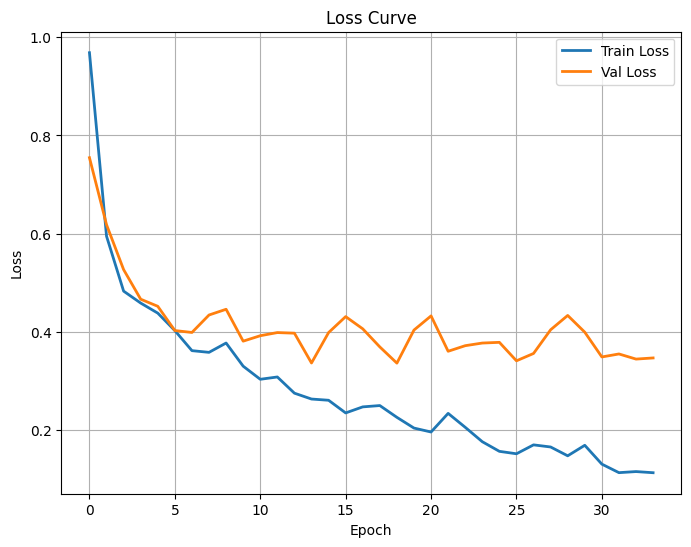

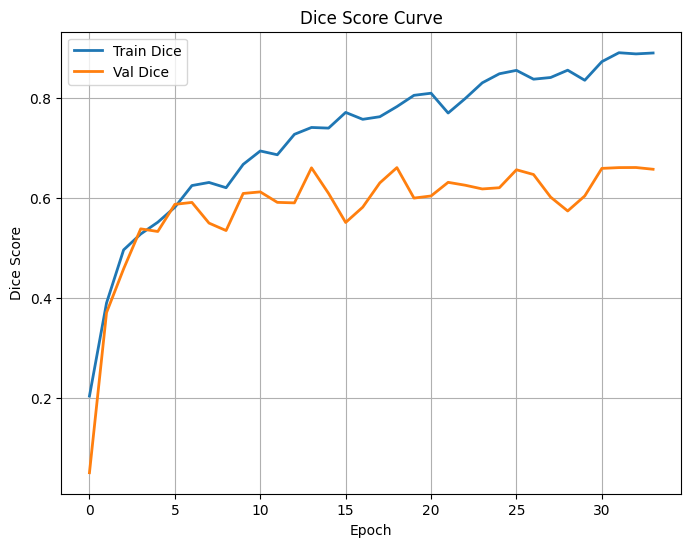

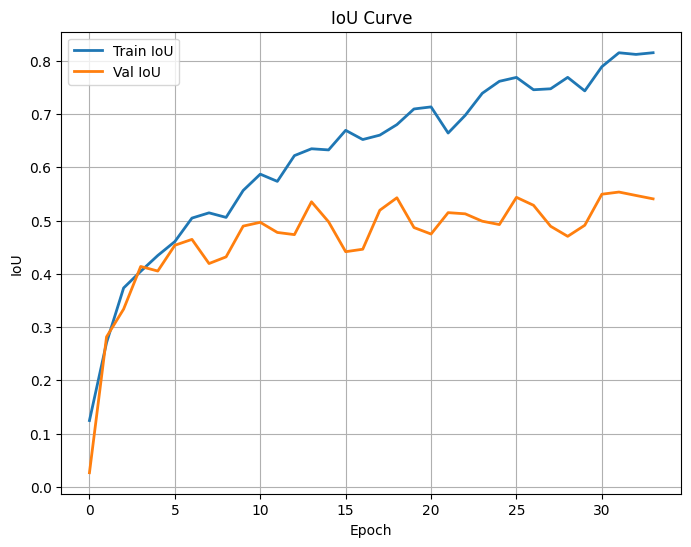

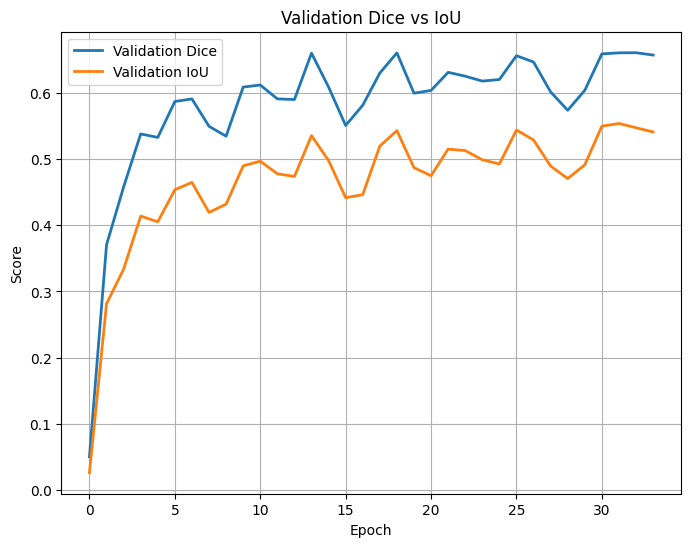

✅ All figures saved successfully!
📁 Location: /kaggle/working/UNet


In [34]:
import matplotlib.pyplot as plt
import os


save_dir = "/kaggle/working/UNet"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Val Loss", linewidth=2)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "loss_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "loss_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()


plt.figure(figsize=(8, 6))
plt.plot(train_dices, label="Train Dice", linewidth=2)
plt.plot(val_dices, label="Val Dice", linewidth=2)
plt.title("Dice Score Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "dice_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "dice_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()

plt.figure(figsize=(8, 6))
plt.plot(train_ious, label="Train IoU", linewidth=2)
plt.plot(val_ious, label="Val IoU", linewidth=2)
plt.title("IoU Curve")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "iou_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "iou_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()


plt.figure(figsize=(8, 6))
plt.plot(val_dices, label="Validation Dice", linewidth=2)
plt.plot(val_ious, label="Validation IoU", linewidth=2)
plt.title("Validation Dice vs IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "validation_dice_vs_iou.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "validation_dice_vs_iou.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()

print("✅ All figures saved successfully!")
print(f"📁 Location: {save_dir}")

In [35]:
import torch
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt

def get_boundary(mask):
    mask = mask.astype(bool)
    return mask ^ binary_erosion(mask) if mask.any() else np.zeros_like(mask, dtype=bool)

def boundary_f1(pred, gt, tolerance=2):
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any(): return 0.0
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    precision = np.mean(gt_dist[pred_b] <= tolerance)
    recall = np.mean(pred_dist[gt_b] <= tolerance)
    return float(2 * precision * recall / (precision + recall + 1e-6))

def surface_distances(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() or not gt.any(): return np.nan, np.nan
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any(): return np.nan, np.nan
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    d_pred_gt, d_gt_pred = gt_dist[pred_b], pred_dist[gt_b]
    assd = (d_pred_gt.sum() + d_gt_pred.sum()) / (len(d_pred_gt) + len(d_gt_pred))
    hd95 = max(np.percentile(d_pred_gt, 95), np.percentile(d_gt_pred, 95))
    return float(assd), float(hd95)

def evaluate_segmentation(model, test_loader, device, threshold=0.4):
    model.eval().to(device)
    dice_all, iou_all, bf1_all, assd_all, hd95_all = [[], []], [[], []], [[], []], [[], []], [[], []]
    TP, FP, FN = [0, 0], [0, 0], [0, 0]
    total_correct = total_pixels = 0

    with torch.inference_mode():
        for imgs, masks, labels in test_loader:
            imgs = imgs.to(device, dtype=torch.float32, non_blocking=True)
            masks = masks.cpu()
            preds = (torch.sigmoid(model(imgs)) > threshold).squeeze(1).cpu()
            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()
            del imgs

            for b in range(preds.size(0)):
                pred = preds[b].numpy().astype(np.uint8)
                gt = masks[b].numpy().astype(np.uint8)

                for c in range(2):
                    p, g = pred == c, gt == c
                    inter = np.logical_and(p, g).sum()
                    p_sum, g_sum = p.sum(), g.sum()
                    union = p_sum + g_sum
                    dice_all[c].append((2 * inter + 1e-6) / (union + 1e-6))
                    iou_all[c].append((inter + 1e-6) / (union - inter + 1e-6))

                    TP[c] += int(np.logical_and(p, g).sum())
                    FP[c] += int(np.logical_and(p, ~g).sum())
                    FN[c] += int(np.logical_and(~p, g).sum())

                    bf1_all[c].append(boundary_f1(p, g, tolerance=2))
                    assd, hd95 = surface_distances(p, g)
                    if not np.isnan(assd):
                        assd_all[c].append(assd)
                        hd95_all[c].append(hd95)

            del preds, masks
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    precision, recall, f1 = [], [], []
    for c in range(2):
        p = TP[c] / (TP[c] + FP[c] + 1e-6)
        r = TP[c] / (TP[c] + FN[c] + 1e-6)
        precision.append(p)
        recall.append(r)
        f1.append(2 * p * r / (p + r + 1e-6))

    def mean(x): return float(np.mean(x)) if x else 0.0
    def std(x): return float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    names = ["Background", "Polyp"]
    print("\n==================== Test Set Metrics ====================")
    print(f"Overall Pixel Accuracy : {total_correct / (total_pixels + 1e-6):.4f}")
    print("----------------------------------------------------------")
    print(f"{'Class':<15}{'Dice':>8}{'IoU':>8}{'BF1':>8}{'ASSD':>9}{'HD95':>9}{'F1':>8}")
    print("----------------------------------------------------------")

    metrics = {}
    for c in range(2):
        d, i, b, a, h = map(mean, [dice_all[c], iou_all[c], bf1_all[c], assd_all[c], hd95_all[c]])
        metrics[c] = {"dice": d, "iou": i, "bf1": b, "assd": a, "hd95": h}
        print(f"{names[c]:<15}{d:8.4f}{i:8.4f}{b:8.4f}{a:9.2f}{h:9.2f}{f1[c]:8.4f}")

    mean_dice = np.mean([metrics[0]["dice"], metrics[1]["dice"]])
    mean_iou = np.mean([metrics[0]["iou"], metrics[1]["iou"]])
    mean_bf1 = np.mean([metrics[0]["bf1"], metrics[1]["bf1"]])
    mean_assd = np.mean([metrics[0]["assd"], metrics[1]["assd"]])
    mean_hd95 = np.mean([metrics[0]["hd95"], metrics[1]["hd95"]])
    mean_f1 = np.mean(f1)

    print("----------------------------------------------------------")
    print(f"{'Mean':<15}{mean_dice:8.4f}{mean_iou:8.4f}{mean_bf1:8.4f}{mean_assd:9.2f}{mean_hd95:9.2f}{mean_f1:8.4f}")
    print("==========================================================")

    accuracy = total_correct / (total_pixels + 1e-6)
    print("\n── Polyp Class (Primary Metrics) ──")
    print(f"Dice       : {metrics[1]['dice']:.4f}")
    print(f"IoU        : {metrics[1]['iou']:.4f}")
    print(f"Boundary F1: {metrics[1]['bf1']:.4f}")
    print(f"ASSD       : {metrics[1]['assd']:.2f}")
    print(f"HD95       : {metrics[1]['hd95']:.2f}")
    print(f"Precision  : {precision[1]:.4f}")
    print(f"Recall     : {recall[1]:.4f}")
    print(f"F1         : {f1[1]:.4f}")
    print("==========================================================\n")

    return {
        "accuracy": accuracy,
        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_boundary_f1": mean_bf1,
        "mean_assd": mean_assd,
        "mean_hd95": mean_hd95,
        "mean_f1": mean_f1,
        "polyp_dice": metrics[1]["dice"],
        "polyp_iou": metrics[1]["iou"],
        "polyp_boundary_f1": metrics[1]["bf1"],
        "polyp_assd": metrics[1]["assd"],
        "polyp_hd95": metrics[1]["hd95"],
        "polyp_precision": precision[1],
        "polyp_recall": recall[1],
        "polyp_f1": f1[1]
    }

results = evaluate_segmentation(model, test_loader, device=device, threshold=0.4)


==================== Test Set Metrics ====================
Overall Pixel Accuracy : 0.9399
----------------------------------------------------------
Class              Dice     IoU     BF1     ASSD     HD95      F1
----------------------------------------------------------
Background       0.9646  0.9353  0.8356     3.88    30.73  0.9671
Polyp            0.6580  0.5538  0.3755    19.50    55.20  0.6530
----------------------------------------------------------
Mean             0.8113  0.7445  0.6056    11.69    42.96  0.8100

── Polyp Class (Primary Metrics) ──
Dice       : 0.6580
IoU        : 0.5538
Boundary F1: 0.3755
ASSD       : 19.50
HD95       : 55.20
Precision  : 0.6991
Recall     : 0.6125
F1         : 0.6530



Image:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png

Ground Truth Mask:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png


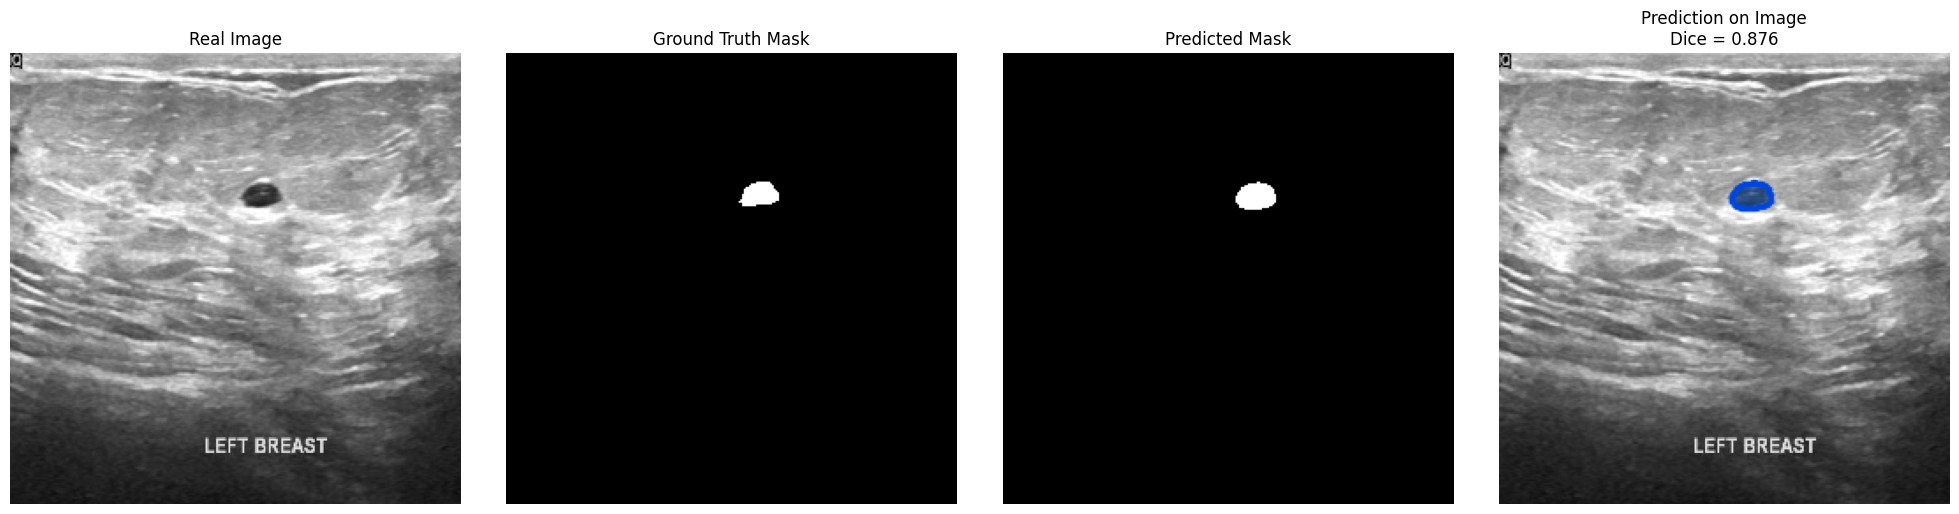


Visualization completed!
Image       : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png
GT Mask     : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png
Dice        : 0.8762

Saved files:
/kaggle/working/XAI/real_image.png
/kaggle/working/XAI/ground_truth_mask.png
/kaggle/working/XAI/predicted_mask.png
/kaggle/working/XAI/predicted_mask_on_image.png


In [36]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


IMAGE_PATH = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png"

MASK_DIR = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks"

SAVE_DIR = "/kaggle/working/UNet/XAI"
os.makedirs(SAVE_DIR, exist_ok=True)


THRESHOLD = 0.4

MASK_COLOR = np.array([30, 120, 255], dtype=np.uint8)

BORDER_COLOR = (0, 70, 220)

MASK_ALPHA = 0.35
BORDER_WIDTH = 2


image_filename = os.path.basename(IMAGE_PATH)

base_name = os.path.splitext(image_filename)[0]

mask_path = os.path.join(
    MASK_DIR,
    base_name + "_mask.png"
)

if not os.path.exists(mask_path):

    found_mask = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:

        temp_path = os.path.join(
            MASK_DIR,
            base_name + "_mask" + ext
        )

        if os.path.exists(temp_path):
            found_mask = temp_path
            break

    if found_mask is None:
        raise FileNotFoundError(
            f"Mask not found for:\n{IMAGE_PATH}\n\n"
            f"Expected mask similar to:\n"
            f"{base_name}_mask.png"
        )

    mask_path = found_mask


print("Image:")
print(IMAGE_PATH)

print("\nGround Truth Mask:")
print(mask_path)


original_pil = Image.open(IMAGE_PATH).convert("RGB")

original_image = np.array(original_pil)


gt_pil = Image.open(mask_path).convert("L")

gt_mask_original = np.array(gt_pil)

gt_mask_original = (
    gt_mask_original > 127
).astype(np.uint8)


model_input = image_transform(original_pil)

model_input = model_input.unsqueeze(0).to(device)


model.eval()

with torch.no_grad():

    output = model(model_input)

    if isinstance(output, (tuple, list)):
        output = output[0]

    probability = torch.sigmoid(output)

    predicted_mask = (
        probability > THRESHOLD
    ).long()


predicted_mask = predicted_mask.squeeze().cpu().numpy().astype(np.uint8)


output_h, output_w = predicted_mask.shape

gt_mask = cv2.resize(
    gt_mask_original,
    (output_w, output_h),
    interpolation=cv2.INTER_NEAREST
)

gt_mask = (
    gt_mask > 0
).astype(np.uint8)


display_image = cv2.resize(
    original_image,
    (output_w, output_h),
    interpolation=cv2.INTER_LINEAR
)

display_image = np.ascontiguousarray(
    display_image,
    dtype=np.uint8
)


gt_mask_display = (
    gt_mask * 255
).astype(np.uint8)


pred_mask_display = (
    predicted_mask * 255
).astype(np.uint8)


overlay = display_image.copy()

prediction_pixels = predicted_mask == 1

overlay[prediction_pixels] = (
    overlay[prediction_pixels].astype(np.float32)
    * (1 - MASK_ALPHA)
    +
    MASK_COLOR.astype(np.float32)
    * MASK_ALPHA
).astype(np.uint8)


contours, _ = cv2.findContours(
    predicted_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = np.ascontiguousarray(overlay)

cv2.drawContours(
    overlay,
    contours,
    -1,
    BORDER_COLOR,
    BORDER_WIDTH,
    lineType=cv2.LINE_AA
)


intersection = np.logical_and(
    predicted_mask == 1,
    gt_mask == 1
).sum()

pred_area = (
    predicted_mask == 1
).sum()

gt_area = (
    gt_mask == 1
).sum()

dice = (
    2.0 * intersection
    /
    (pred_area + gt_area + 1e-8)
)


save_path = os.path.join(
    SAVE_DIR,
    "real_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(display_image)

plt.title(
    "Real Image",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "ground_truth_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Ground Truth Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Predicted Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask_on_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(overlay)

plt.title(
    f"Predicted Mask on Image\nDice = {dice:.3f}",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(display_image)
axes[0].set_title("Real Image")

axes[1].imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1].set_title("Ground Truth Mask")

axes[2].imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("Predicted Mask")

axes[3].imshow(overlay)
axes[3].set_title(
    f"Prediction on Image\nDice = {dice:.3f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

plt.close()


print("\n" + "=" * 60)
print("Visualization completed!")
print("=" * 60)

print(f"Image       : {IMAGE_PATH}")
print(f"GT Mask     : {mask_path}")
print(f"Dice        : {dice:.4f}")

print("\nSaved files:")

print(
    os.path.join(
        SAVE_DIR,
        "real_image.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "ground_truth_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask_on_image.png"
    )

)

print("=" * 60)